# Exploratory data analysis


First, select the name of a dataset stored in the dataset folder. The data is expected to conform to the standards of BasicTS

In [32]:
dataset = '../data/'+'PEMS08/' # change the PEMS04/ PEMS08/ METR-LA/ BeijingAirQuality/

In [33]:
# imports
import os
import json
import numpy as np
import pickle
import scipy.sparse as sp
from scipy.sparse import linalg
from scipy import stats
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose


In [34]:
def load_dataset_description(folder_path):
    """
    Loads and prints key metadata from the 'desc.json' file in the specified folder.

    Args:
        folder_path (str): The path to the folder containing the 'desc.json' file.
    """
    
    # Construct the full path to the desc.json file
    json_path = os.path.join(folder_path, 'desc.json')
    
    # Check if the file exists
    if not os.path.exists(json_path):
        print(f"Error: desc.json not found in the folder '{folder_path}'")
        return
        
    try:
        # Load the JSON data
        with open(json_path, 'r') as f:
            metadata = json.load(f)
            
        print("--- Dataset Description ---")
        
        # General Information
        print(f"Dataset Name: {metadata.get('name', 'N/A')}")
        print(f"Domain: {metadata.get('domain', 'N/A')}")
        print(f"Number of Time Slices: {metadata.get('shape', 'N/A')[0]}")
        print(f"Number of Nodes (Time Series): {metadata.get('shape', 'N/A')[1]}")
        print(f"Number of features per Node: {metadata.get('shape', 'N/A')[2]}")
        
        print("\n--- Feature and Structure ---")
        
        # Feature Descriptions
        print(f"Features description: {', '.join(metadata.get('feature_description', 'N/A'))}")
        print(f"Time step length: {metadata.get('frequency (minutes)', 'N/A')} minutes")
        print(f"Prior Graph Structures: {'Present' if metadata.get('has_graph') else 'Not Present'}")
        
        print("\n--- Model Settings ---")
        
        # Regular Settings
        settings = metadata.get('regular_settings', {})
        print(f"Input Sequence Length: {settings.get('INPUT_LEN', 'N/A')}")
        print(f"Output Sequence Length: {settings.get('OUTPUT_LEN', 'N/A')}")
        
        # Data Splits
        ratios = settings.get('TRAIN_VAL_TEST_RATIO',['N/A', 'N/A', 'N/A'])
        print(f"Training Data Ratio: {ratios[0]}")
        print(f"Validation Data Ratio: {ratios[1]}")
        print(f"Test Data Ratio: {ratios[2]}")
        
        # Normalization and Evaluation
        print(f"Individual Channel Normalization: {'Yes' if settings.get('NORM_EACH_CHANNEL', False) else 'No'}")
        print(f"Renormalize during Evaluation: {'Yes' if settings.get('RESCALE', False) else 'No'}")
        print(f"Evaluation Metrics: {', '.join(settings.get('METRICS', 'N/A'))}")
        print(f"Outlier Handling: {settings.get('NULL_VAL', 'N/A')}")
        
    except json.JSONDecodeError:
        print(f"Error: Could not decode the JSON file at '{json_path}'. Please check its format.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Here we can see the description and settings of the dataset

In [35]:
load_dataset_description(dataset)

--- Dataset Description ---
Dataset Name: PEMS08
Domain: traffic flow
Number of Time Slices: 17856
Number of Nodes (Time Series): 170
Number of features per Node: 3

--- Feature and Structure ---
Features description: traffic flow, time of day, day of week
Time step length: 5 minutes
Prior Graph Structures: Present

--- Model Settings ---
Input Sequence Length: 12
Output Sequence Length: 12
Training Data Ratio: 0.6
Validation Data Ratio: 0.2
Test Data Ratio: 0.2
Individual Channel Normalization: No
Renormalize during Evaluation: Yes
Evaluation Metrics: MAE, RMSE, MAPE
Outlier Handling: 0.0


In [36]:
def load_dataset_as_memmap(folder_path, data_file='data.dat') -> np.ndarray:
    """
    Loads the raw time series data from a numpy.memmap file.

    Args:
        folder_path (str): The path to the folder containing the data files.
        data_file (str): The name of the numpy.memmap file.

    Returns:
        tuple: A tuple containing the numpy.memmap object and a boolean indicating
               success or failure.
    """
    json_path = os.path.join(folder_path, 'desc.json')
    data_path = os.path.join(folder_path, data_file)

    # Check if files exist
    if not os.path.exists(json_path):
        print(f"Error: desc.json not found at '{json_path}'")
        return None, False

    if not os.path.exists(data_path):
        print(f"Error: {data_file} not found at '{data_path}'")
        return None, False

    try:
        # Load metadata to get shape
        with open(json_path, 'r') as f:
            metadata = json.load(f)

        shape = metadata.get('shape')

        if shape is None:
            print("Error: 'shape' not found in desc.json. Cannot load data.")
            return None, False

        print(f"Attempting to load data with shape {shape}...")

        # Load the memmap file
        data = np.memmap(data_path, dtype='float32',
                         mode='r', shape=tuple(shape))
        print("Data loaded successfully as a numpy.memmap object.")
        print(f"Data shape: {data.shape}")

        return data, True

    except json.JSONDecodeError:
        print(f"Error: Could not decode the JSON file at '{json_path}'.")
        return None, False
    except Exception as e:
        print(f"An unexpected error occurred while loading the data: {e}")
        return None, False

Here we load the actual data, starting with the time series data

In [37]:
data, res = load_dataset_as_memmap(dataset)
print(f'Successful loading: {res}')

Attempting to load data with shape [17856, 170, 3]...
Data loaded successfully as a numpy.memmap object.
Data shape: (17856, 170, 3)
Successful loading: True


Now, lets load the adjacency matrix, if any

In [38]:
# these were taken from inside BasicTS' repository
def calculate_symmetric_normalized_laplacian(adj: np.ndarray) -> np.matrix:
    """
    Calculate the symmetric normalized Laplacian.

    The symmetric normalized Laplacian matrix is given by:
    L^{Sym} = I - D^{-1/2} A D^{-1/2}, where L is the unnormalized Laplacian, 
    D is the degree matrix, and A is the adjacency matrix.

    Args:
        adj (np.ndarray): Adjacency matrix A.

    Returns:
        np.matrix: Symmetric normalized Laplacian L^{Sym}.
    """

    adj = sp.coo_matrix(adj)
    degree = np.array(adj.sum(1)).flatten()
    degree_inv_sqrt = np.power(degree, -0.5)
    degree_inv_sqrt[np.isinf(degree_inv_sqrt)] = 0.0
    matrix_degree_inv_sqrt = sp.diags(degree_inv_sqrt)

    laplacian = sp.eye(adj.shape[0]) - matrix_degree_inv_sqrt.dot(adj).dot(matrix_degree_inv_sqrt).tocoo()
    return laplacian

def calculate_scaled_laplacian(adj: np.ndarray, lambda_max: int = 2, undirected: bool = True) -> np.matrix:
    """
    Scale the normalized Laplacian for use in Chebyshev polynomials.

    Rescale the Laplacian matrix such that its eigenvalues are within the range [-1, 1].

    Args:
        adj (np.ndarray): Adjacency matrix A.
        lambda_max (int, optional): Maximum eigenvalue, defaults to 2.
        undirected (bool, optional): If True, treats the graph as undirected, defaults to True.

    Returns:
        np.matrix: Scaled Laplacian matrix.
    """

    if undirected:
        adj = np.maximum(adj, adj.T)

    laplacian = calculate_symmetric_normalized_laplacian(adj)

    if lambda_max is None:
        lambda_max, _ = linalg.eigsh(laplacian, 1, which='LM')
        lambda_max = lambda_max[0]

    laplacian = sp.csr_matrix(laplacian)
    identity = sp.identity(laplacian.shape[0], format='csr', dtype=laplacian.dtype)

    scaled_laplacian = (2 / lambda_max) * laplacian - identity
    return scaled_laplacian

def calculate_symmetric_message_passing_adj(adj: np.ndarray) -> np.matrix:
    """
    Calculate the renormalized message-passing adjacency matrix as proposed in GCN.

    The message-passing adjacency matrix is defined as A' = D^{-1/2} (A + I) D^{-1/2}.

    Args:
        adj (np.ndarray): Adjacency matrix A.

    Returns:
        np.matrix: Renormalized message-passing adjacency matrix.
    """

    adj = adj + np.eye(adj.shape[0], dtype=np.float32)
    adj = sp.coo_matrix(adj)

    row_sum = np.array(adj.sum(1)).flatten()
    d_inv_sqrt = np.power(row_sum, -0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0

    d_mat_inv_sqrt = sp.diags(d_inv_sqrt)
    mp_adj = d_mat_inv_sqrt.dot(adj).transpose().dot(d_mat_inv_sqrt).astype(np.float32)

    return mp_adj

def calculate_transition_matrix(adj: np.ndarray) -> np.matrix:
    """
    Calculate the transition matrix as proposed in DCRNN and Graph WaveNet.

    The transition matrix is defined as P = D^{-1} A, where D is the degree matrix.

    Args:
        adj (np.ndarray): Adjacency matrix A.

    Returns:
        np.matrix: Transition matrix P.
    """

    adj = sp.coo_matrix(adj)
    row_sum = np.array(adj.sum(1)).flatten()
    d_inv = np.power(row_sum, -1)
    d_inv[np.isinf(d_inv)] = 0.0

    d_mat = sp.diags(d_inv)
    prob_matrix = d_mat.dot(adj).astype(np.float32).todense()

    return prob_matrix

In [39]:
def load_pkl(pickle_file: str) -> object:
    """
    Load data from a pickle file.

    Args:
        pickle_file (str): Path to the pickle file.

    Returns:
        object: Loaded object from the pickle file.
    """

    try:
        with open(pickle_file, 'rb') as f:
            pickle_data = pickle.load(f)
    except UnicodeDecodeError:
        with open(pickle_file, 'rb') as f:
            pickle_data = pickle.load(f, encoding='latin1')
    except Exception as e:
        print(f'Unable to load data from {pickle_file}: {e}')
        raise
    return pickle_data

def load_adj(file_path: str, adj_type: str):
    """
    Load and preprocess an adjacency matrix.

    Args:
        file_path (str): Path to the file containing the adjacency matrix.
        adj_type (str): Type of adjacency matrix preprocessing. Options: 'scalap', 'normlap', 'symnadj', 'transition', 'doubletransition', 'identity', 'original'.

    Returns:
        list: List of processed adjacency matrices.
        np.ndarray: Raw adjacency matrix.
    """

    try:
        _, _, adj_mx = load_pkl(file_path)
    except ValueError:
        adj_mx = load_pkl(file_path)

    if adj_type == 'scalap':
        adj = [calculate_scaled_laplacian(adj_mx).astype(np.float32).todense()]
    elif adj_type == 'normlap':
        adj = [calculate_symmetric_normalized_laplacian(adj_mx).astype(np.float32).todense()]
    elif adj_type == 'symnadj':
        adj = [calculate_symmetric_message_passing_adj(adj_mx).astype(np.float32).todense()]
    elif adj_type == 'transition':
        adj = [calculate_transition_matrix(adj_mx).T]
    elif adj_type == 'doubletransition':
        adj = [calculate_transition_matrix(adj_mx).T, calculate_transition_matrix(adj_mx.T).T]
    elif adj_type == 'identity':
        adj = [np.diag(np.ones(adj_mx.shape[0])).astype(np.float32)]
    elif adj_type == 'original':
        adj = [adj_mx]
    else:
        raise ValueError('Undefined adjacency matrix type.')

    return adj, adj_mx

Here is the matrix, in np.matrix form

In [40]:
raw_input_matrix = load_pkl(dataset+'adj_mx.pkl')

In [41]:
adj, adj_mx = load_adj(dataset+'adj_mx.pkl', 'doubletransition')

In [42]:
adj_mx[5]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [43]:
adj[0][5]

matrix([[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.2       , 0.2       , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0

Some info:

In [44]:
print(f'Number of nodes in the matrix: {adj[0].shape[0]}')
print(f'Number of edges in the matrix: {np.count_nonzero(adj[0])}')

Number of nodes in the matrix: 170
Number of edges in the matrix: 548


In [45]:
def calculate_graph_metrics(adj_matrix: np.ndarray, directed: bool = True):
    """
    Calculates structural and statistical metrics for a graph represented by an adjacency matrix.
    
    Args:
        adj_matrix (np.ndarray): N x N adjacency matrix (can be weighted).
        directed (bool): True if the graph is directed, False if undirected.

    Returns:
        dict: A dictionary of graph metrics.
    """
    # --- Input validation ---
    if not isinstance(adj_matrix, np.ndarray) or adj_matrix.ndim != 2 or adj_matrix.shape[0] != adj_matrix.shape[1]:
        raise ValueError("Input must be a square NumPy adjacency matrix.")
    
    # Ensure no negative weights
    adj_matrix = np.abs(adj_matrix)
    num_nodes = adj_matrix.shape[0]

    # --- Binary adjacency for unweighted measures ---
    binary_adj = (adj_matrix > 1e-6).astype(int)

    # --- Degrees ---
    if directed:
        out_degrees = np.sum(binary_adj, axis=1)
        in_degrees = np.sum(binary_adj, axis=0)
        degrees = out_degrees + in_degrees
    else:
        degrees = np.sum(binary_adj, axis=1)

    # --- Basic stats on degree distribution ---
    degree_stats = {
        "min_degree": int(np.min(degrees)),
        "max_degree": int(np.max(degrees)),
        "mean_degree": float(np.mean(degrees)),
        "median_degree": float(np.median(degrees)),
        "mode_degree": int(stats.mode(degrees, keepdims=True)[0][0]),
        "std_degree": float(np.std(degrees)),
        "q1_degree": float(np.percentile(degrees, 25)),
        "q3_degree": float(np.percentile(degrees, 75)),
    }

    total_edges = np.sum(binary_adj)
    if not directed:
        total_edges //= 2  # avoid double-counting

    # --- Weighted measures ---
    existing_weights = adj_matrix[adj_matrix > 0]
    avg_connection_strength = np.mean(existing_weights) if existing_weights.size > 0 else 0.0

    # --- Graph-level metrics ---
    possible_edges = num_nodes * (num_nodes - 1)
    if not directed:
        possible_edges /= 2

    density = total_edges / possible_edges if possible_edges > 0 else 0.0

    # Reciprocity (for directed graphs)
    reciprocity = None
    if directed:
        mutual_edges = np.sum((binary_adj > 0) & (binary_adj.T > 0)) // 2
        reciprocity = mutual_edges / total_edges if total_edges > 0 else 0.0

    # --- Clustering coefficient ---
    # Triangles = trace(A^3) / 6 (undirected), or /3 (directed)
    A3 = np.linalg.matrix_power(binary_adj, 3)
    triangles = np.trace(A3)
    if directed:
        clustering_coeff = triangles / (num_nodes * (num_nodes - 1) * (num_nodes - 2)) if num_nodes > 2 else 0.0
    else:
        clustering_coeff = triangles / (6 * total_edges) if total_edges > 0 else 0.0

    # --- Compile results ---
    metrics = {
        "num_nodes": num_nodes,
        "total_edges": int(total_edges),
        "density": float(density),
        "avg_connection_strength": float(avg_connection_strength),
        "clustering_coefficient": float(clustering_coeff),
        **degree_stats
    }

    if directed:
        metrics.update({
            "reciprocity": float(reciprocity),
            "mean_in_degree": float(np.mean(in_degrees)),
            "mean_out_degree": float(np.mean(out_degrees)),
        })

    return metrics


In [46]:
def draw_directed_graph_from_adj(adj_matrix: np.ndarray, title: str = "Directed Graph"):
    """
    Draws a directed graph represented by an adjacency matrix.

    Args:
        adj_matrix (np.ndarray): The adjacency matrix (N x N).
        title (str): The title for the plot.
    """
    if not isinstance(adj_matrix, np.ndarray) or adj_matrix.ndim != 2 or adj_matrix.shape[0] != adj_matrix.shape[1]:
        print("Error: Input must be a square NumPy adjacency matrix.")
        return

    # Create a directed graph from the adjacency matrix
    G = nx.DiGraph(adj_matrix)

    plt.figure(figsize=(12, 10))
    
    # Use a spring layout for better visualization of node clusters
    pos = nx.spring_layout(G, k=0.15, iterations=50) 
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue', alpha=0.9)
    
    # Draw edges
    # We can filter edges to only draw those with a significant weight if desired
    # For a binary adjacency, all non-zero entries are "significant"
    edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    nx.draw_networkx_edges(G, pos, edgelist=edges, arrowsize=20, width=1.5, edge_color='gray', alpha=0.6)
    
    # Draw labels (node numbers)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    
    plt.title(title, size=18)
    plt.axis('off') # Hide axes for a cleaner graph visualization
    plt.show()

Here we can visualize the graph, altough due to density, it is often unreadable

On most data from the speed sensors, the matrix is constructed by road network distances

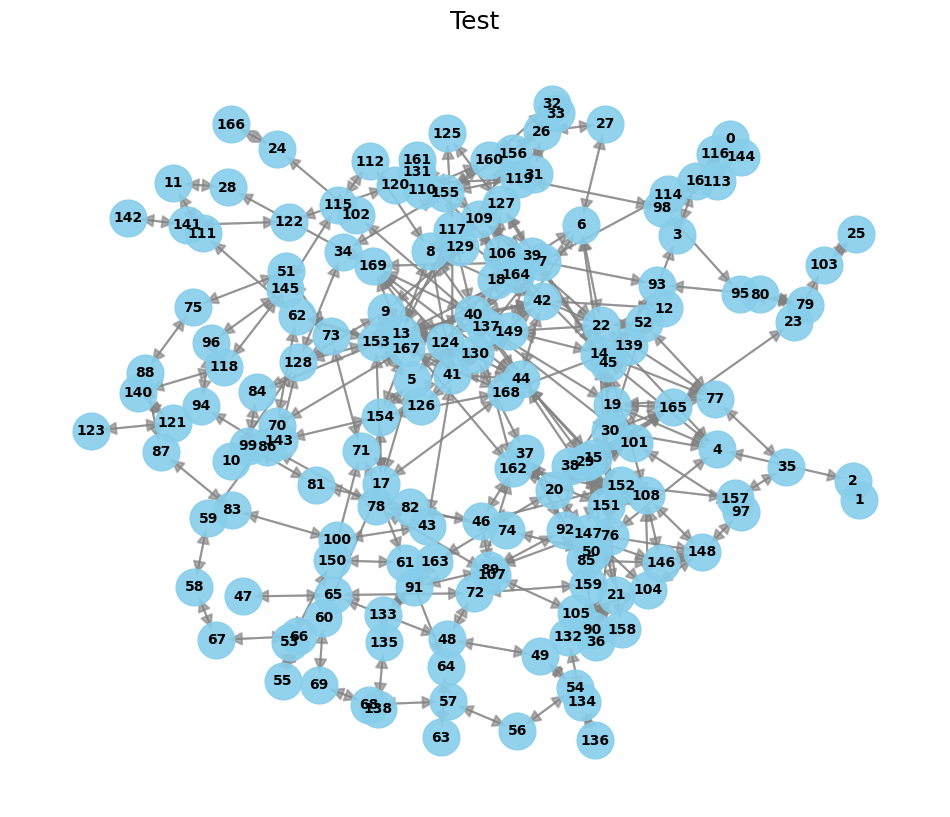

In [47]:
draw_directed_graph_from_adj(adj[0], 'Test')

In [48]:
def plot_adjacency_matrix_heatmap(adj_matrix: np.ndarray, title: str = "Adjacency Matrix Heatmap"):
    """
    Plots the adjacency matrix as a heatmap to visualize graph structure.

    Args:
        adj_matrix (np.ndarray): The N x N adjacency matrix.
        title (str): The title for the plot.
    """
    if not isinstance(adj_matrix, np.ndarray) or adj_matrix.ndim != 2 or adj_matrix.shape[0] != adj_matrix.shape[1]:
        print("Error: Input must be a square NumPy adjacency matrix.")
        return


    # Create the heatmap
    plt.figure(figsize=(16, 16))
    sns.heatmap(adj_matrix, cmap="viridis", cbar=True)

    plt.title(title, fontsize=16)
    plt.xlabel('Node Index', fontsize=12)
    plt.ylabel('Node Index', fontsize=12)
    plt.show()

A better visalization using heatmap, also saved to a png for easier control

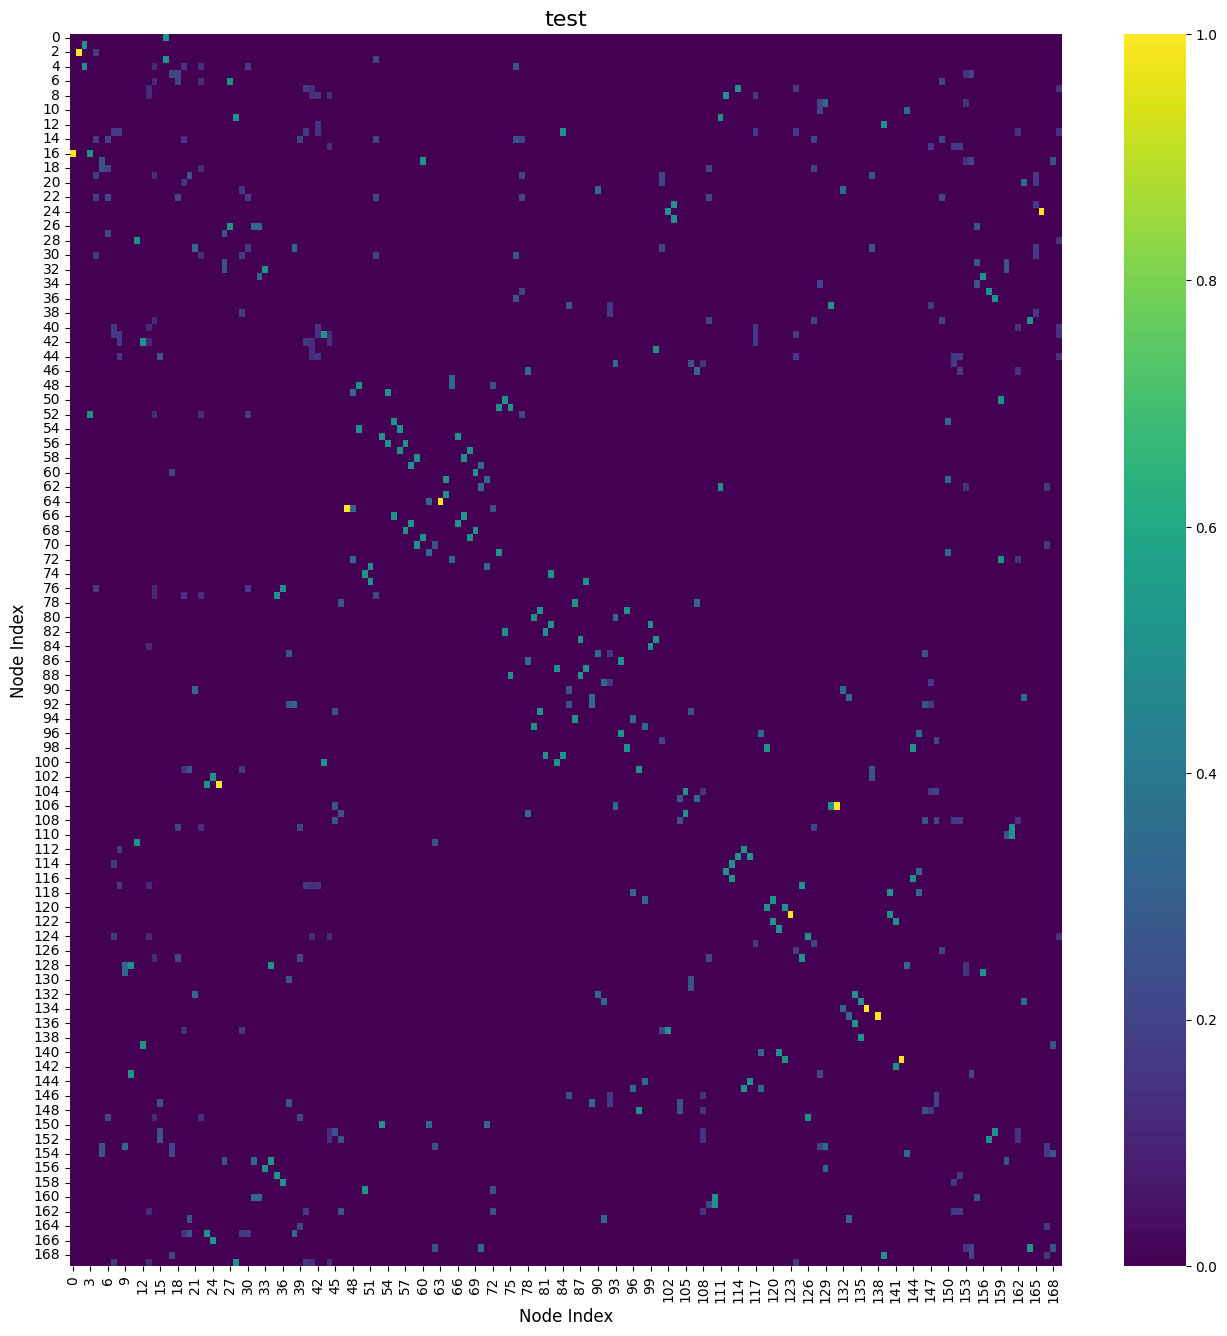

In [49]:
plot_adjacency_matrix_heatmap(adj[0], 'test')

## Now, some time series graphs

In [50]:
def plot_node_time_series(data_array: np.ndarray, node_index: int, feature_index: int = 0, title: str = None, x_0:int = None, x_1:int=None):
    """
    Plots the time series data for a single node.

    Args:
        data_array (np.ndarray): The time series data array with shape [L, N, C].
        node_index (int): The index of the node (N) to plot.
        feature_index (int, optional): The index of the feature (C) to plot, defaults to 0.
        title (str, optional): A custom title for the plot.
        x_0 (int, optional): time step at which to start the plot
        x_1 (int, optional): time step at which to end the plot
    """
    L, N, C = data_array.shape

    if not (0 <= node_index < N):
        print(f"Error: Node index {node_index} is out of bounds. Valid range is 0 to {N-1}.")
        return

    if not (0 <= feature_index < C):
        print(f"Error: Feature index {feature_index} is out of bounds. Valid range is 0 to {C-1}.")
        return

    # Extract the time series for the specified node and feature
    time_series = data_array[:, node_index, feature_index]
    if x_0 and x_1:
        time_series = time_series[x_0:x_1]
    elif x_0:
        time_series = time_series[x_0:]
    elif x_1:
        time_series = time_series[:x_1]
    # Create a DataFrame for easy plotting with seaborn
    df = pd.DataFrame({'value': time_series, 'time_step': range(len(time_series))})
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=df, x='time_step', y='value')
    
    if title is None:
        plt.title(f'Time Series for Node {node_index} (Feature {feature_index})', fontsize=16)
    else:
        plt.title(title, fontsize=16)
        
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()


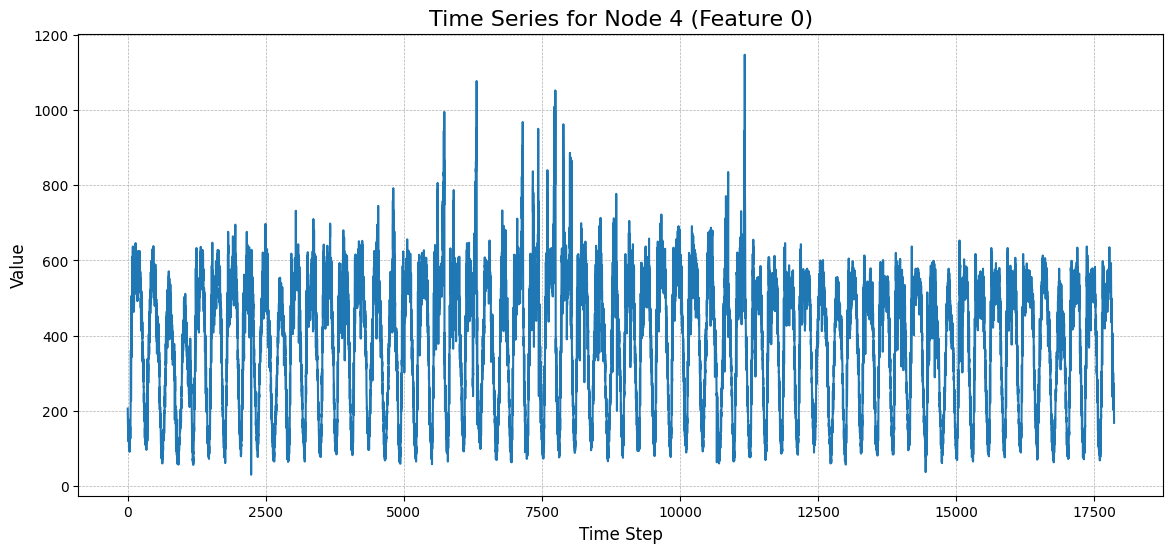

In [51]:
plot_node_time_series(data, 4, 0)

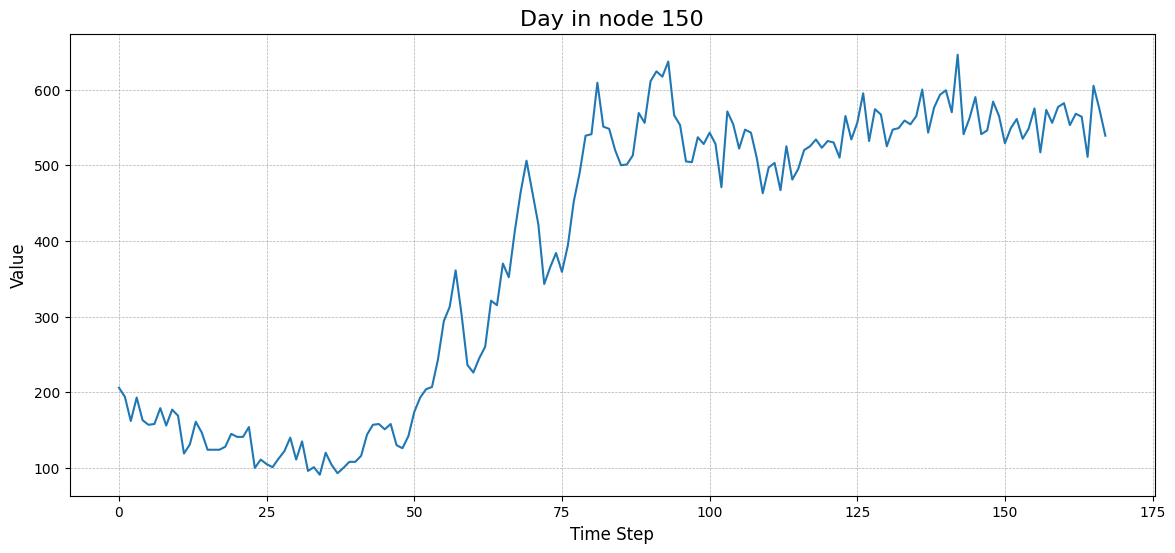

In [52]:
# plot of a day in the pems bay dataset: 5 mins for a time step = 24*60/5 = 288 time steps for a day
plot_node_time_series(data, 4, 0, 'Day in node 150', 0, 24*7)

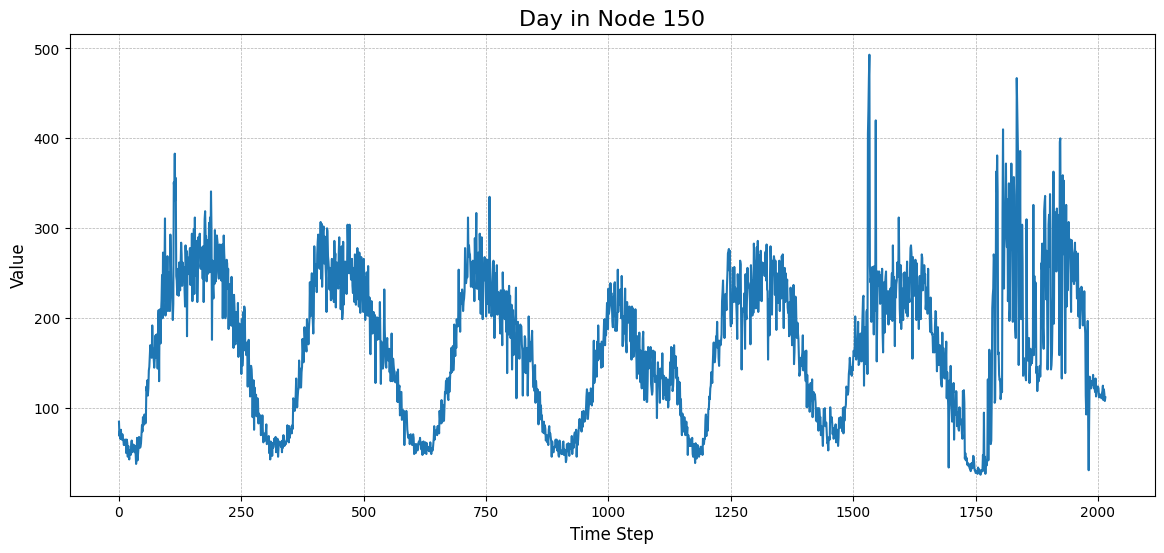

In [53]:
# and a week. Here we can begin to see a clear periodicity in the series
plot_node_time_series(data, 150, 0, 'Day in Node 150', 0, 288*7)

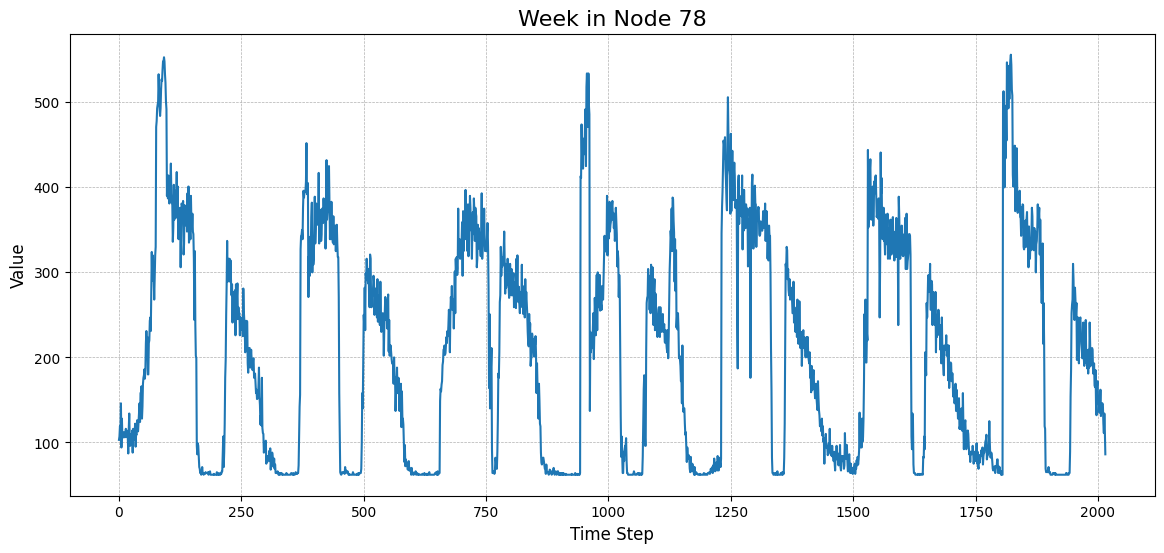

In [54]:
plot_node_time_series(data, 78, 0, 'Week in Node 78',0, 288*7)
#here we can clearly see that in pems bay, nodes work very diferently, but they all share some kind of cicle. 

In [55]:
def plot_time_series_decomposition(data_array: np.ndarray, node_index: int, frequency: int, feature_index: int = 0):
    """
    Performs and plots a time series decomposition for a single node.

    This function decomposes the time series into trend, seasonal, and residual components.
    It requires the frequency of the seasonal pattern in terms of time steps.

    Args:
        data_array (np.ndarray): The time series data array with shape [L, N, C].
        node_index (int): The index of the node to plot.
        frequency (int): The number of time steps per seasonal cycle (e.g., 288 for a daily cycle with 5-minute frequency).
        feature_index (int, optional): The index of the feature to plot, defaults to 0.
    """
    L, N, C = data_array.shape

    if not (0 <= node_index < N):
        print(f"Error: Node index {node_index} is out of bounds. Valid range is 0 to {N-1}.")
        return

    if not (0 <= feature_index < C):
        print(f"Error: Feature index {feature_index} is out of bounds. Valid range is 0 to {C-1}.")
        return
        
    if L < frequency * 2:
        print(f"Not enough data points ({L}) to perform decomposition with frequency {frequency}. At least two full cycles are recommended.")
        return

    # Extract the time series for the specified node and feature
    time_series = data_array[:, node_index, feature_index]

    # Perform additive decomposition
    # Additive model: Y(t) = T(t) + S(t) + R(t) is a good default for data with constant seasonal amplitude.
    try:
        result = seasonal_decompose(time_series, model='additive', period=frequency)
        # Plot the decomposed components
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
        ax1.plot(result.observed)
        ax1.set_title('Observed')
        ax2.plot(result.trend)
        ax2.set_title('Trend')
        ax3.plot(result.seasonal)
        ax3.set_title('Seasonal')
        ax4.plot(result.resid)
        ax4.set_title('Residual')
        
        plt.suptitle(f'Time Series Decomposition for Node {node_index}', fontsize=18)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    except ValueError as e:
        print(f"Decomposition failed. The data might not be suitable for the specified frequency. Error: {e}")

And here we have a seasonal, trend, residual decomposition. I assumed a daily trend (which checks out)

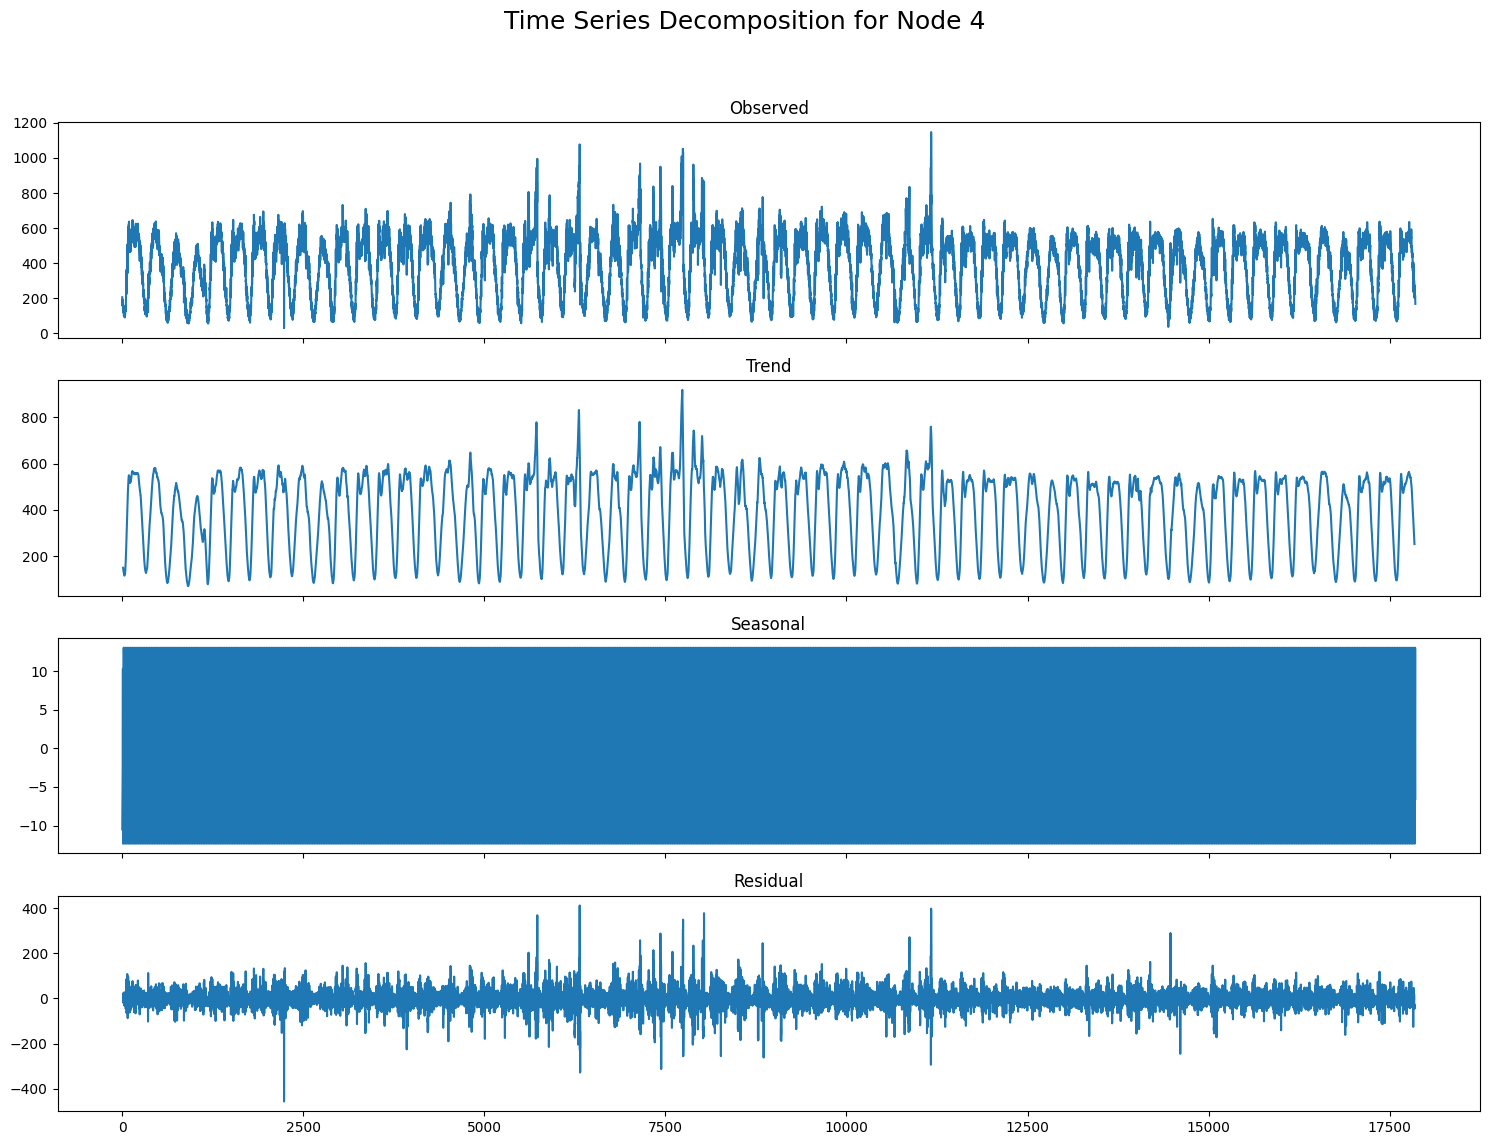

In [56]:
plot_time_series_decomposition(data, 4, 24, 0)

### Now the meat of the issue: let's create correlation matrixes

Starting with transforming the data for the np function which will do the calculations, we need to do a dimension reduction. Usually the target feature is on index 0, but I will create a function just in case we might need a different target

In [57]:

def reshape_time_series_for_correlation(data_array: np.ndarray, feature_index: int = 0) -> np.ndarray:
    """
    Extracts a single feature and reshapes the time series data for correlation analysis.

    The input shape is [L, N, C] (Time Steps, Nodes, Features).
    The output shape is [L, N] (Time Steps, Nodes), which is required by np.corrcoef.

    Args:
        data_array (np.ndarray): The time series data array with shape [L, N, C].
        feature_index (int, optional): The index of the feature (C) to use. Defaults to the first feature (0), which is usually the target.

    Returns:
        np.ndarray: The reshaped array with shape [L, N].
    """
    L, N, C = data_array.shape

    if not (0 <= feature_index < C):
        raise ValueError(
            f"Feature index {feature_index} is out of bounds. Valid range is 0 to {C-1}.")

    #(slicing keeps the [L, N, 1] shape)
    single_feature_data = data_array[:, :, feature_index]
    # .
    # so we squeeze it back in
    shaped_data = np.squeeze(single_feature_data)

    return shaped_data


In [58]:
shaped_data = reshape_time_series_for_correlation(data)

Here we calculate the correlation matrix. For now I am using a linear correlation, Pearson. This will probably be heavily modified, but for now I am testing out the workflow

In [59]:
def calculate_pearson_correlation_matrix(shaped_data: np.ndarray) -> np.ndarray:
    """
    Calculates the Pearson (linear) correlation coefficient matrix between all pairs of nodes.

    The input is expected to be [L, N] (Time Steps, Nodes).
    The output is an [N, N] matrix where C[i, j] is the correlation between Node i and Node j.
    Args:
        shaped_data (np.ndarray): The time series data with shape [L, N].
    Returns:
        np.ndarray: The N x N Pearson correlation matrix.
    """
    
    # Numpy expects rows as variables and columns as data. We have [L, N], so we need to transpose it to [N, L]
    data_transposed = shaped_data.T
    # Calculate the Pearson correlation coefficient matrix
    # The result, corr_matrix, is an N x N matrix.
    corr_matrix = np.corrcoef(data_transposed)    
    return corr_matrix

In [60]:
corr_matrix = calculate_pearson_correlation_matrix(shaped_data)

In [61]:
corr_matrix
# so here we can see the correlation matrix. Numbers are pretty high, as expected, due to daily cycles and stuff. So we do have some leaking

array([[1.        , 0.8462603 , 0.78157251, ..., 0.87475559, 0.91407974,
        0.76517818],
       [0.8462603 , 1.        , 0.87117825, ..., 0.92316857, 0.82436747,
        0.86234809],
       [0.78157251, 0.87117825, 1.        , ..., 0.83055545, 0.74767214,
        0.82527012],
       ...,
       [0.87475559, 0.92316857, 0.83055545, ..., 1.        , 0.86429299,
        0.83731107],
       [0.91407974, 0.82436747, 0.74767214, ..., 0.86429299, 1.        ,
        0.73067342],
       [0.76517818, 0.86234809, 0.82527012, ..., 0.83731107, 0.73067342,
        1.        ]])

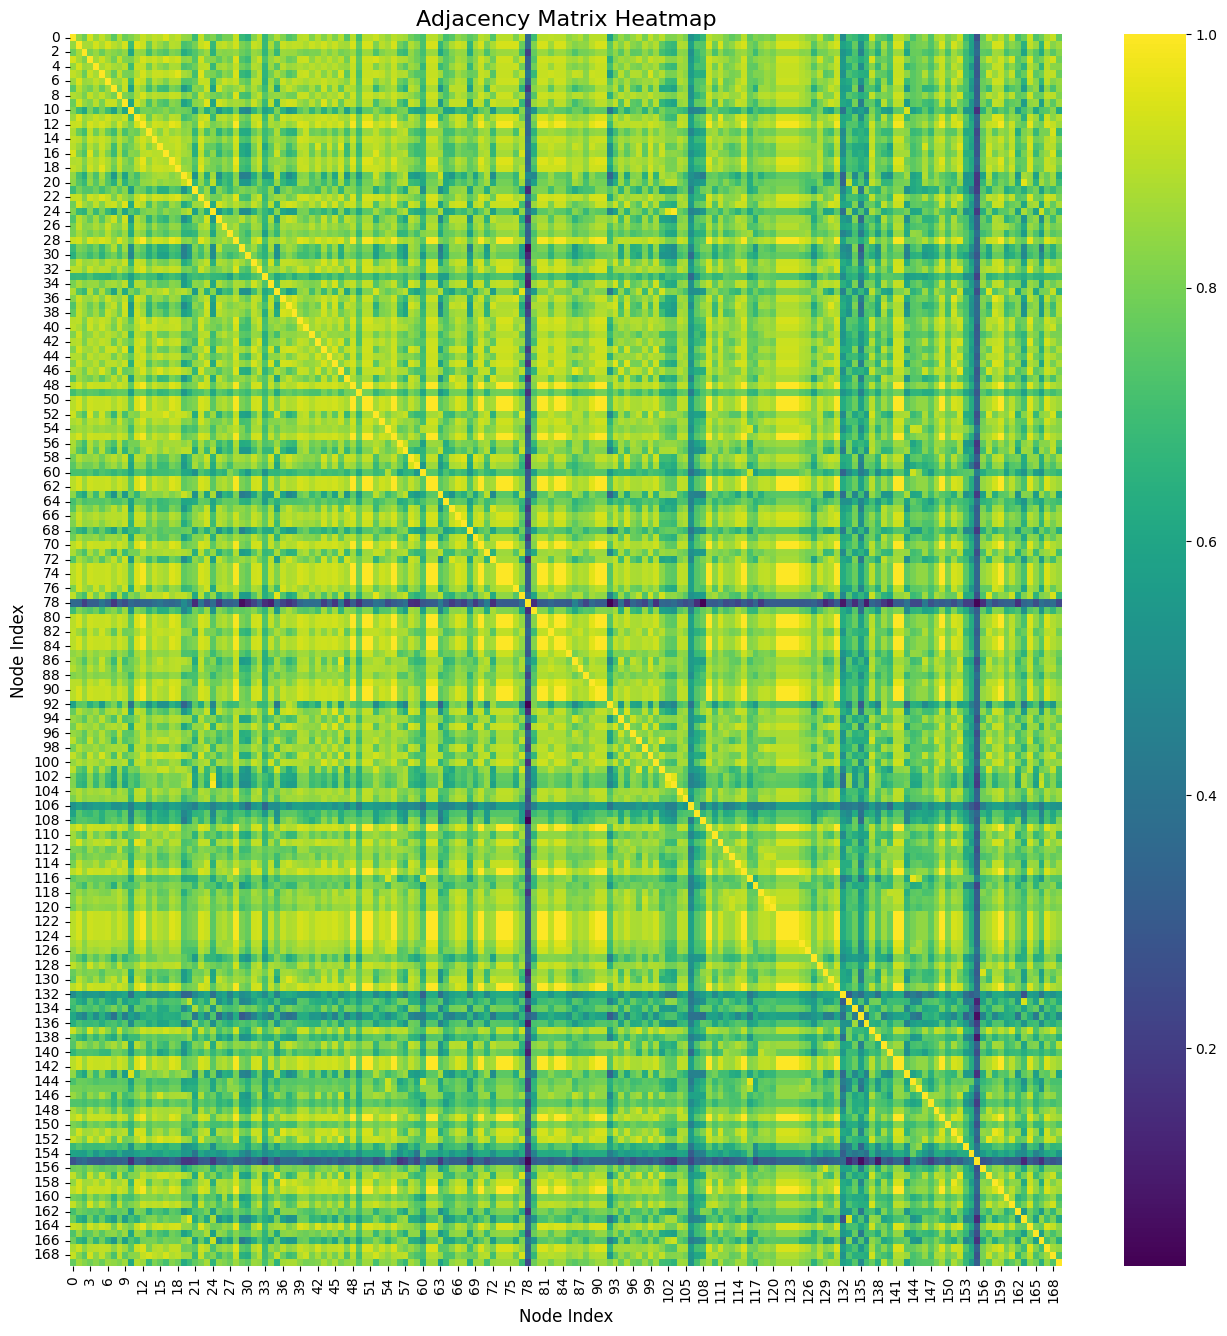

In [62]:
plot_adjacency_matrix_heatmap(corr_matrix)

So, in the current matrix we have some quite suspicious values. Most of the nodes correlate quite highly with each other, although that might be expected due to the fact that traffic within an urban system works pretty much the same everywhere. But it could also be temporal leakage, whatever. <br> For now I'll continue with this pretty simple matrix, and we'll later see if other measures or perhaps some deseasonalizing of the data might be better. <br> For the creation of the matrix I will:
- Make it absolute (altough it was already positive on the examples I tried)
- Choose top-k neighbours for each node, so top-k values in each row. I will choose a number similar to the average degree in the original adjacency matrix
- Clear the matrix save for chosen neighbours
- For each row, normalize through L1

In [63]:
def top_k_adjacency_matrix(corr_matrix: np.ndarray, k: int, normalize: 'str' = None, norm_strength: float = 1) -> np.ndarray:
    """
    Creates a sparser adjacency matrix by selecting the top-k strongest
    correlations (edges) for each node and applying row-wise normalization.

    Args:
        corr_matrix (np.ndarray): The N x N Pearson correlation matrix.
        k (int): The number of outgoing connections to keep for each node.
        normalize (str): Options: 'row-l1', 'row-softmax', 'softmax', 'row-minmax', 'minmax', 'make-1. If None, no normalization is applied. Make-1 will make chosen edges 1.
        strength: if normalizing, allows for adjustment of normalization strength by modulating the division. A norm_strenth of 2 on a L1 norm will make elements sum to 2
    Returns:
        np.ndarray: The N x N sparse adjacency matrix.
    """
    N = corr_matrix.shape[0]

    # Make sure matrix is positive
    adj = np.abs(corr_matrix)
    np.fill_diagonal(adj, 0)  # Remove self-loops

    # Create a mask to keep only the top-k values for each row
    mask = np.zeros_like(adj, dtype=bool)
    
    # For each node (row)
    for i in range(N):
        # Get the *indices* that would sort the row by weight (in descending order). np already does this
        # np.argsort returns ascending, so we use [::-1] to reverse it
        top_k_indices = np.argsort(adj[i, :])[::-1][:k]
        mask[i, top_k_indices] = True # fill in the mask accordingly
        
    # Apply the mask: marvels of numpy
    sparse_adj = np.where(mask, adj, 0)
    if normalize:
        global_min = sparse_adj[sparse_adj > 0].min() if np.any(sparse_adj > 0) else 0
        global_max = sparse_adj.max()
        zero_mask = sparse_adj < 1e-6 # for methods that would affect 0s, we don't actually want them to be modified

        if normalize == 'row-l1':
            # Row-wise L1 normalization (sum of each row = norm_strength)
            row_sums = sparse_adj.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1  # Avoid division by zero
            normalized_adj = norm_strength * sparse_adj / row_sums
            
        elif normalize == 'row-softmax':
            # Row-wise Softmax: Exponentiate and normalize each row sum to 1
            exp_adj = np.exp(sparse_adj)
            exp_adj[zero_mask] = 0 # reset original 0 to 0
            row_sums = exp_adj.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1 
            normalized_adj = norm_strength * exp_adj / row_sums
            
        elif normalize == 'softmax':
            # Global Softmax: Normalize all elements by the sum of all elements
            exp_adj = np.exp(sparse_adj)
            exp_adj[zero_mask] = 0 # reset original 0 to 0
            global_sum = exp_adj.sum()
            normalized_adj = norm_strength * exp_adj / global_sum
            
        elif normalize == 'row-minmax':
            # Row-wise Min-Max normalization
            # Note: Since the values are already between 0 and 1, this mostly handles the post-sparsification range
            normalized_adj = np.copy(sparse_adj)
            for i in range(N):
                row = sparse_adj[i, :]
                row_min = row[row > 0].min() if np.any(row > 0) else 0
                row_max = row.max()
                
                denominator = row_max - row_min
                if denominator > 1e-6:
                    normalized_adj[i, :][~zero_mask[i,:]] = (row[~zero_mask[i,:]] - row_min) / denominator
                else:
                    normalized_adj[i, :] = row # Keep as is if all values are the same
            
        elif normalize == 'minmax':
            # Global Min-Max normalization
            denominator = global_max - global_min
            normalized_adj = np.copy(sparse_adj)
            if denominator > 1e-6:
                # Apply normalization only to the non-zero elements. ~ negates the mask
                normalized_adj[~zero_mask] = (sparse_adj[~zero_mask] - global_min) / denominator
                # Zero elements remain zero
        elif normalize == 'make-1':
            normalized_adj = (~zero_mask) # we can just cast the matrix here
        else:
            print(f"Warning: Unknown normalization type '{normalize}'. No normalization applied.")
            return sparse_adj

        return normalized_adj.astype(np.float32)

    else:
        return sparse_adj.astype(np.float32)

In [64]:
own_adj = top_k_adjacency_matrix(corr_matrix, 3, 'make-1')

In [65]:
calculate_graph_metrics(adj_mx)

{'num_nodes': 170,
 'total_edges': 548,
 'density': 0.019074138531152106,
 'avg_connection_strength': 1.0,
 'clustering_coefficient': 9.944806324896822e-05,
 'min_degree': 2,
 'max_degree': 18,
 'mean_degree': 6.447058823529412,
 'median_degree': 4.0,
 'mode_degree': 4,
 'std_degree': 3.602306066471836,
 'q1_degree': 4.0,
 'q3_degree': 8.0,
 'reciprocity': 0.5,
 'mean_in_degree': 3.223529411764706,
 'mean_out_degree': 3.223529411764706}

In [66]:
own_adj

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)


NORM: None
 {'num_nodes': 170, 'total_edges': 510, 'density': 0.01775147928994083, 'avg_connection_strength': 0.9174583554267883, 'clustering_coefficient': 4.35085276714236e-05, 'min_degree': 3, 'max_degree': 27, 'mean_degree': 6.0, 'median_degree': 5.0, 'mode_degree': 3, 'std_degree': 3.7306362806930844, 'q1_degree': 3.0, 'q3_degree': 7.0, 'reciprocity': 0.1803921568627451, 'mean_in_degree': 3.0, 'mean_out_degree': 3.0}


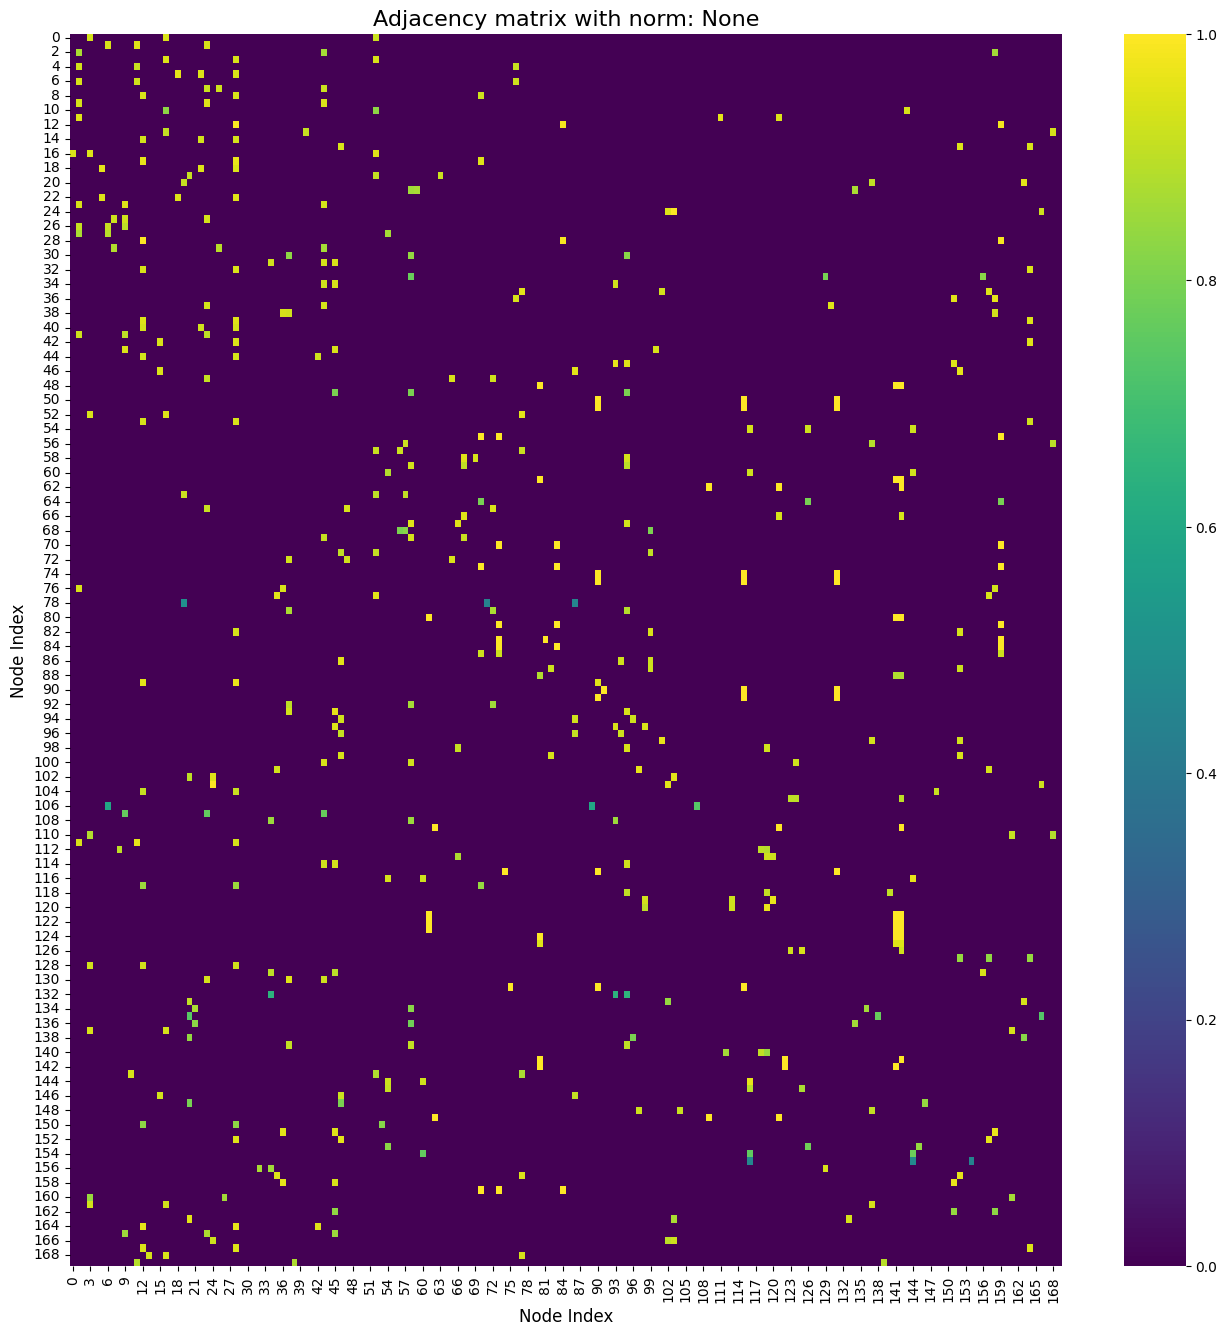


NORM: row-l1
 {'num_nodes': 170, 'total_edges': 510, 'density': 0.01775147928994083, 'avg_connection_strength': 0.3333333432674408, 'clustering_coefficient': 4.35085276714236e-05, 'min_degree': 3, 'max_degree': 27, 'mean_degree': 6.0, 'median_degree': 5.0, 'mode_degree': 3, 'std_degree': 3.7306362806930844, 'q1_degree': 3.0, 'q3_degree': 7.0, 'reciprocity': 0.1803921568627451, 'mean_in_degree': 3.0, 'mean_out_degree': 3.0}


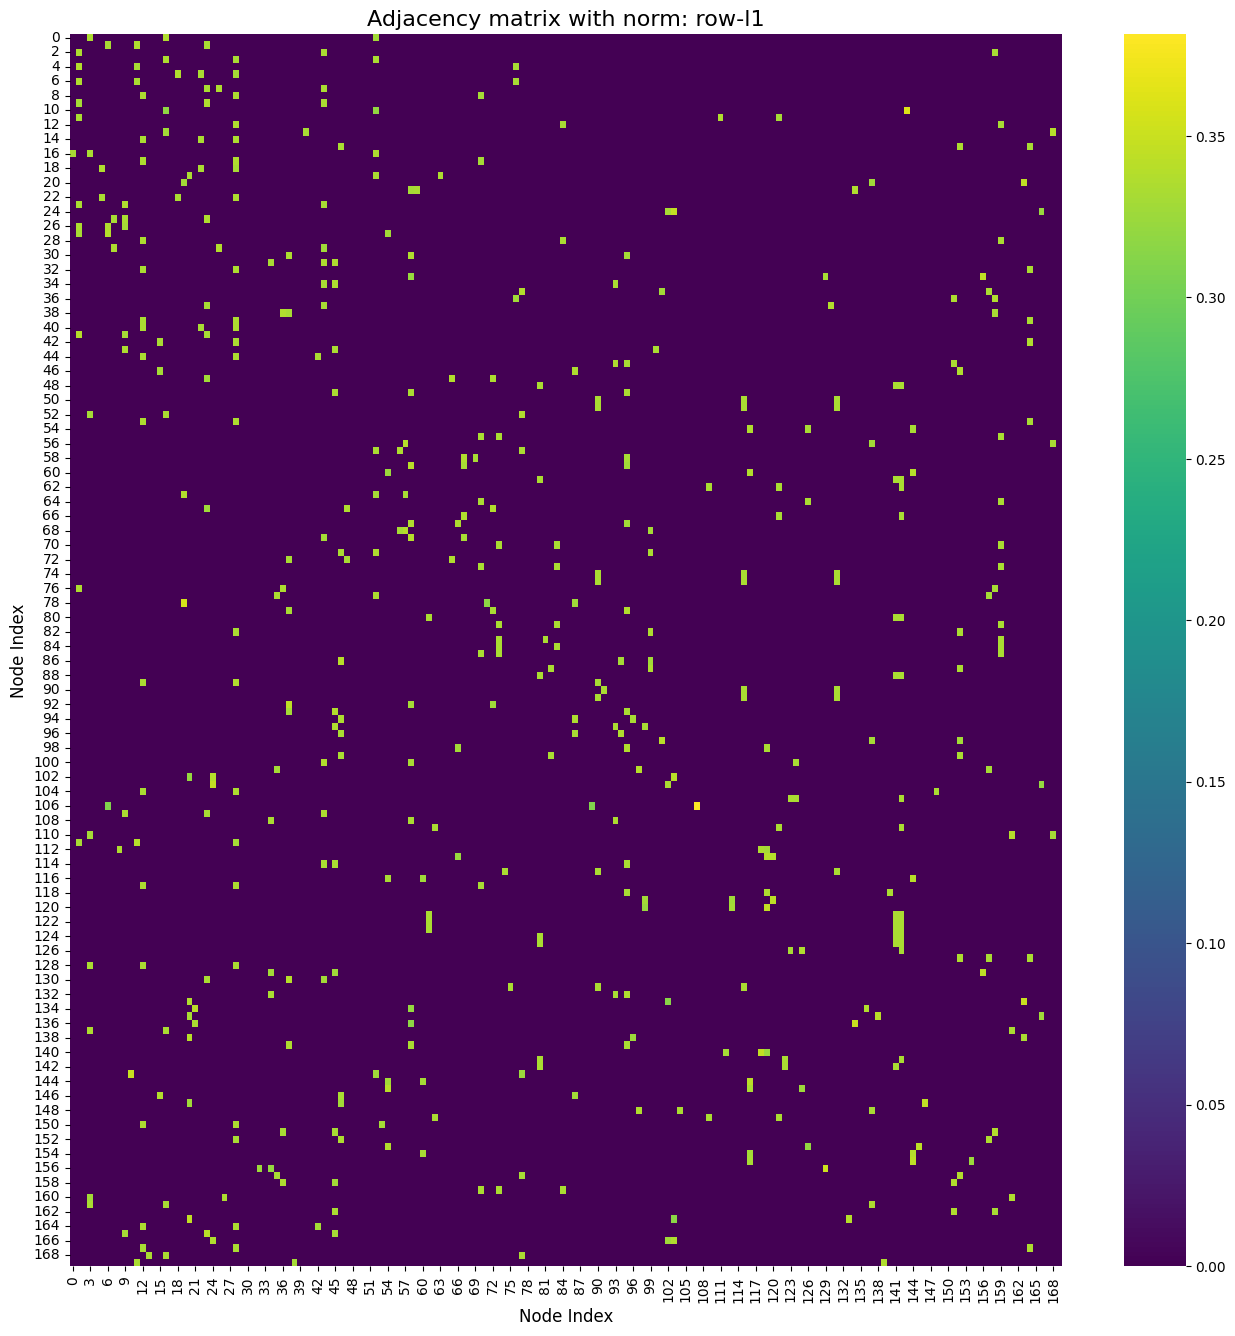


NORM: row-softmax
 {'num_nodes': 170, 'total_edges': 510, 'density': 0.01775147928994083, 'avg_connection_strength': 0.3333333432674408, 'clustering_coefficient': 4.35085276714236e-05, 'min_degree': 3, 'max_degree': 27, 'mean_degree': 6.0, 'median_degree': 5.0, 'mode_degree': 3, 'std_degree': 3.7306362806930844, 'q1_degree': 3.0, 'q3_degree': 7.0, 'reciprocity': 0.1803921568627451, 'mean_in_degree': 3.0, 'mean_out_degree': 3.0}


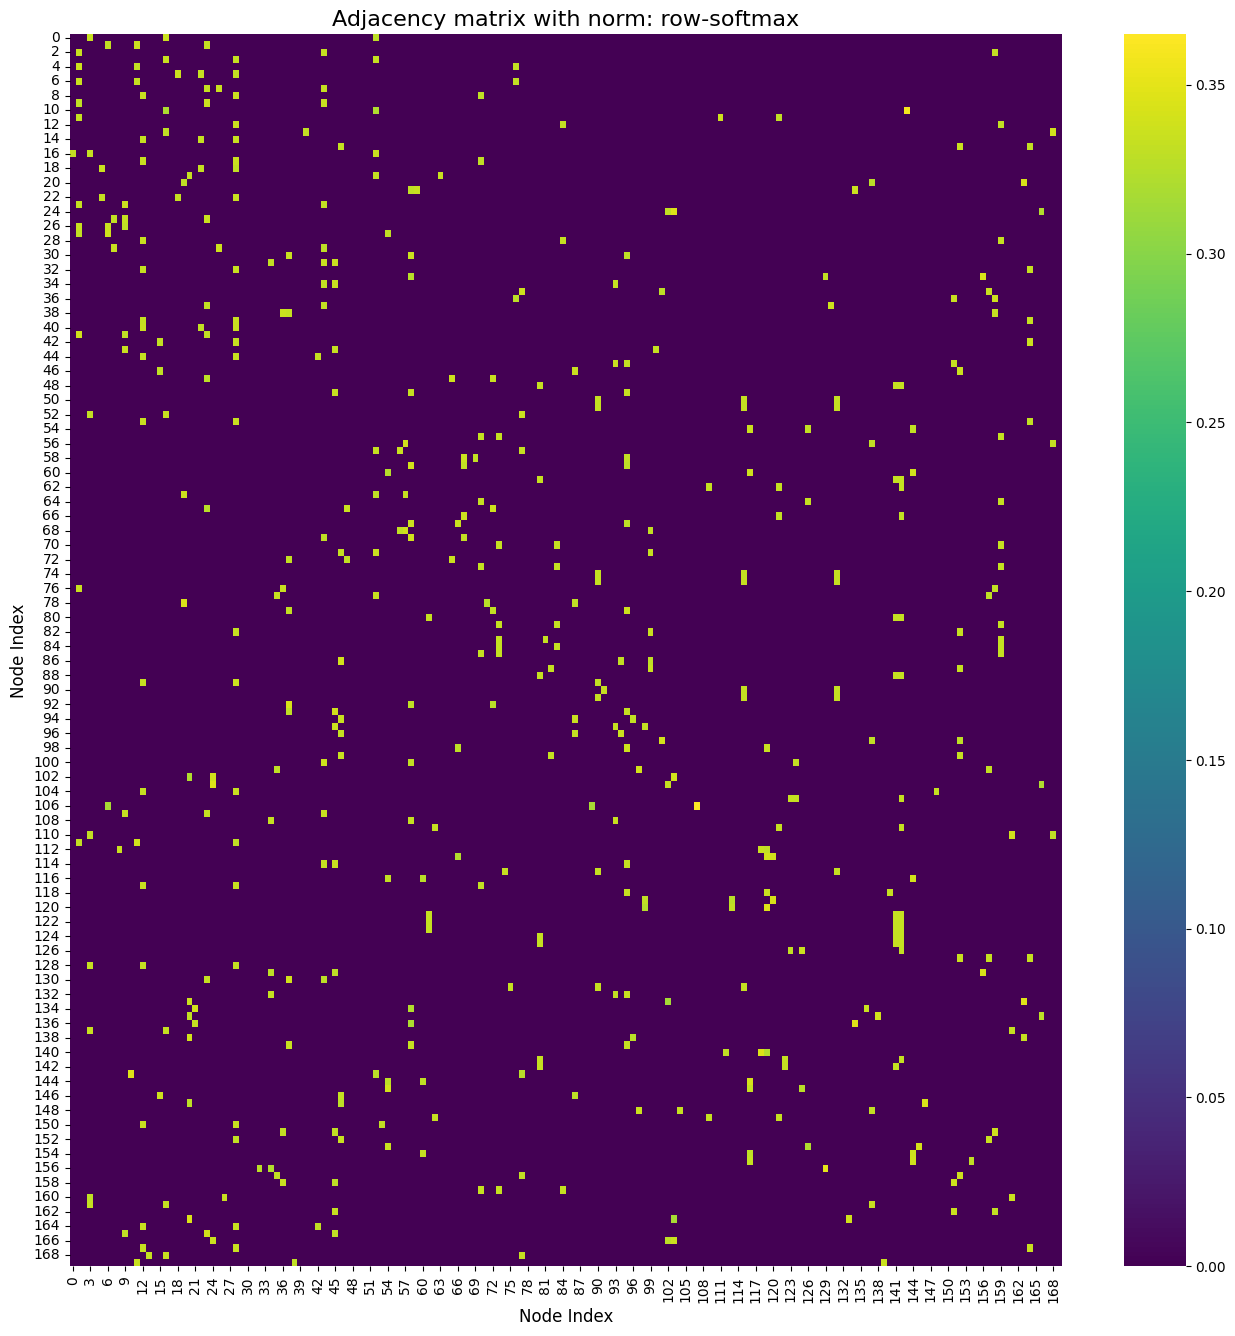


NORM: softmax
 {'num_nodes': 170, 'total_edges': 510, 'density': 0.01775147928994083, 'avg_connection_strength': 0.0019607844296842813, 'clustering_coefficient': 4.35085276714236e-05, 'min_degree': 3, 'max_degree': 27, 'mean_degree': 6.0, 'median_degree': 5.0, 'mode_degree': 3, 'std_degree': 3.7306362806930844, 'q1_degree': 3.0, 'q3_degree': 7.0, 'reciprocity': 0.1803921568627451, 'mean_in_degree': 3.0, 'mean_out_degree': 3.0}


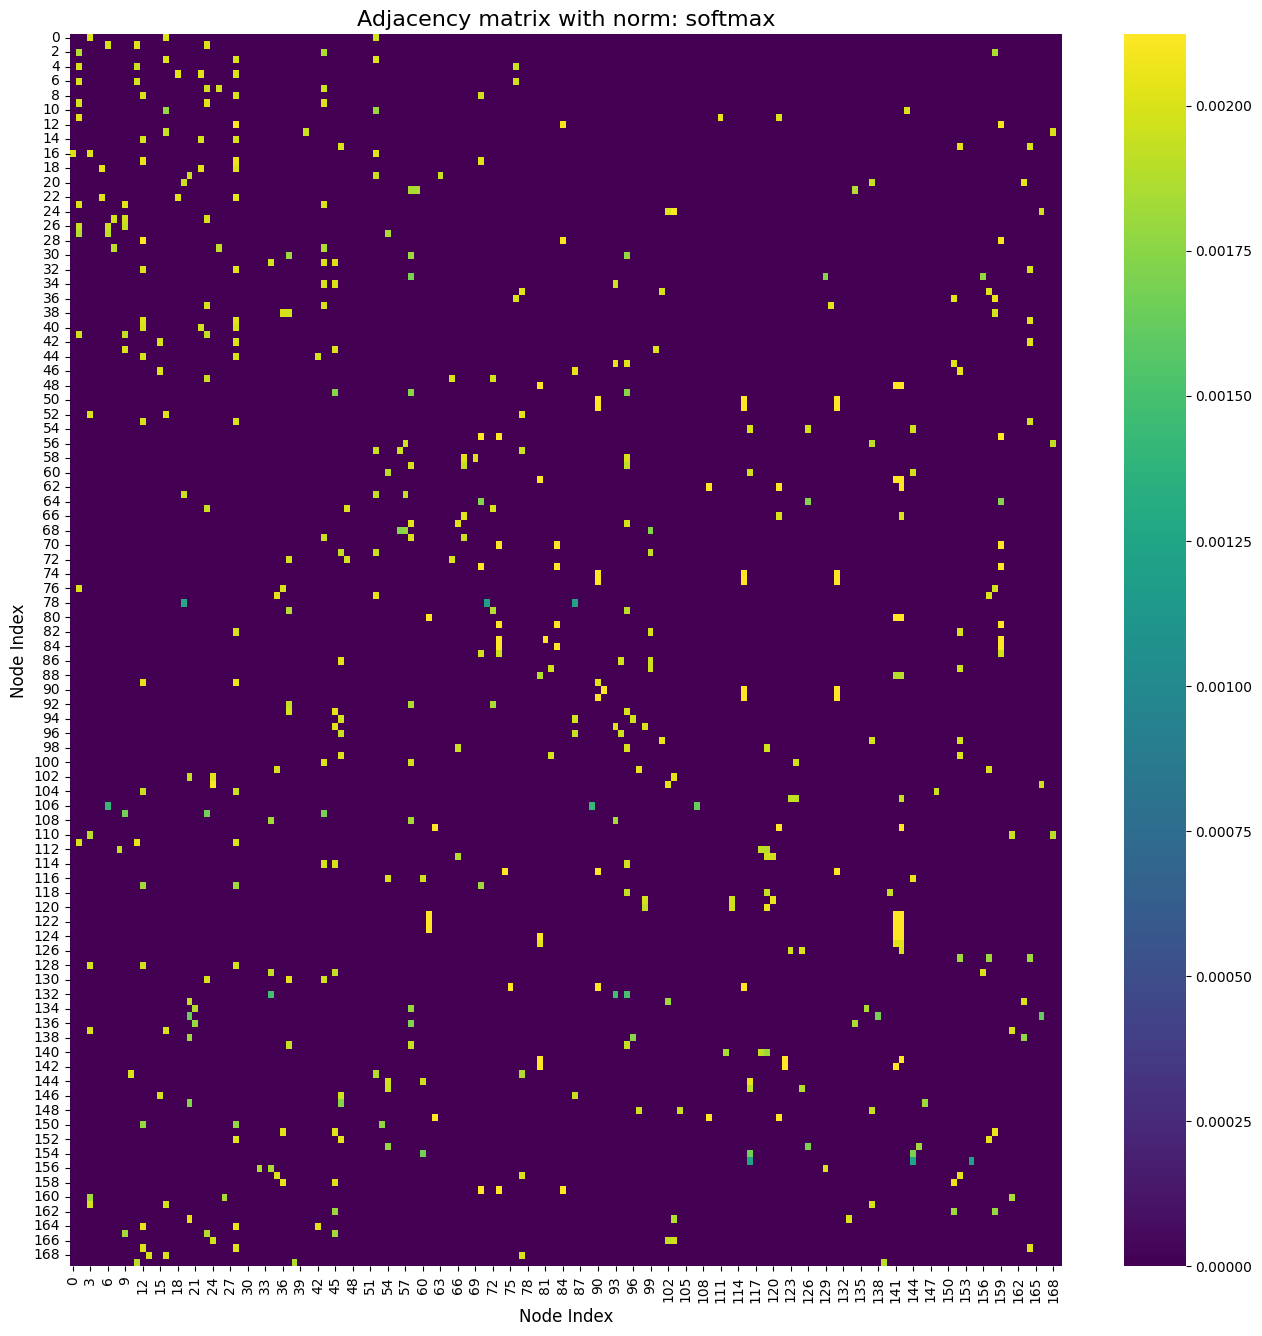


NORM: row-minmax
 {'num_nodes': 170, 'total_edges': 359, 'density': 0.012495649147232857, 'avg_connection_strength': 0.7807785272598267, 'clustering_coefficient': 2.4862015812242056e-05, 'min_degree': 1, 'max_degree': 20, 'mean_degree': 4.223529411764706, 'median_degree': 3.0, 'mode_degree': 2, 'std_degree': 2.771181402720148, 'q1_degree': 2.0, 'q3_degree': 5.0, 'reciprocity': 0.1977715877437326, 'mean_in_degree': 2.111764705882353, 'mean_out_degree': 2.111764705882353}


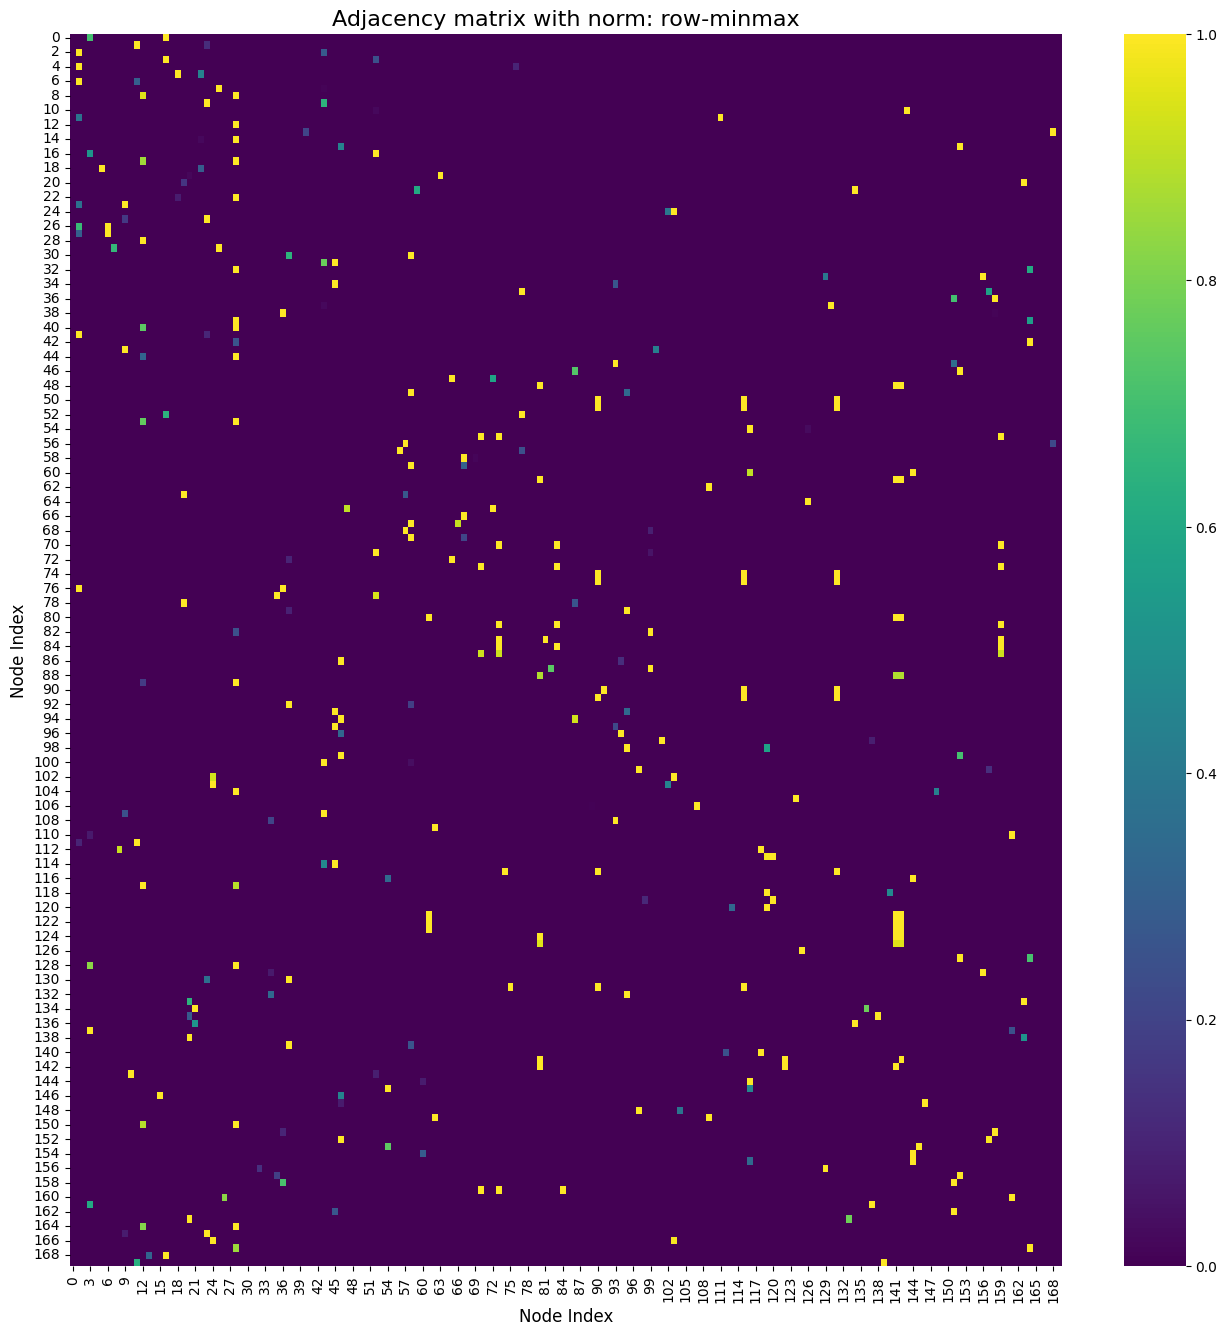


NORM: minmax
 {'num_nodes': 170, 'total_edges': 509, 'density': 0.01771667246780369, 'avg_connection_strength': 0.8544570803642273, 'clustering_coefficient': 4.35085276714236e-05, 'min_degree': 2, 'max_degree': 27, 'mean_degree': 5.988235294117647, 'median_degree': 5.0, 'mode_degree': 3, 'std_degree': 3.7400664279947153, 'q1_degree': 3.0, 'q3_degree': 7.0, 'reciprocity': 0.1807465618860511, 'mean_in_degree': 2.9941176470588236, 'mean_out_degree': 2.9941176470588236}


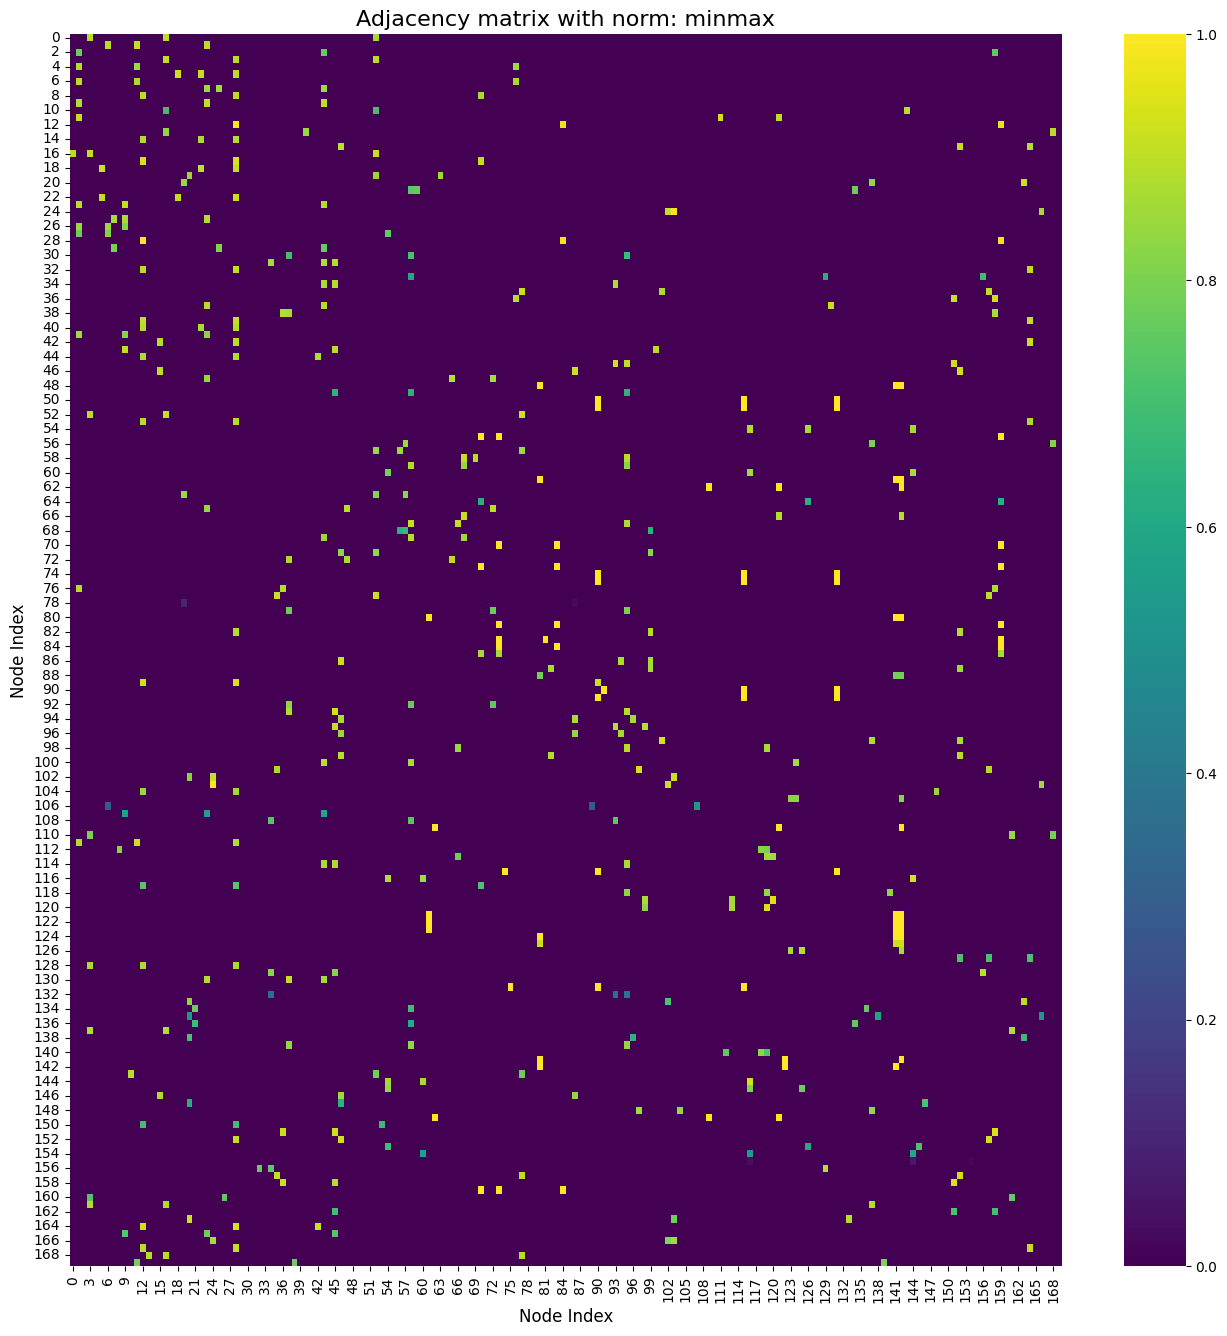


NORM: make-1
 {'num_nodes': 170, 'total_edges': 510, 'density': 0.01775147928994083, 'avg_connection_strength': 1.0, 'clustering_coefficient': 4.35085276714236e-05, 'min_degree': 3, 'max_degree': 27, 'mean_degree': 6.0, 'median_degree': 5.0, 'mode_degree': 3, 'std_degree': 3.7306362806930844, 'q1_degree': 3.0, 'q3_degree': 7.0, 'reciprocity': 0.1803921568627451, 'mean_in_degree': 3.0, 'mean_out_degree': 3.0}


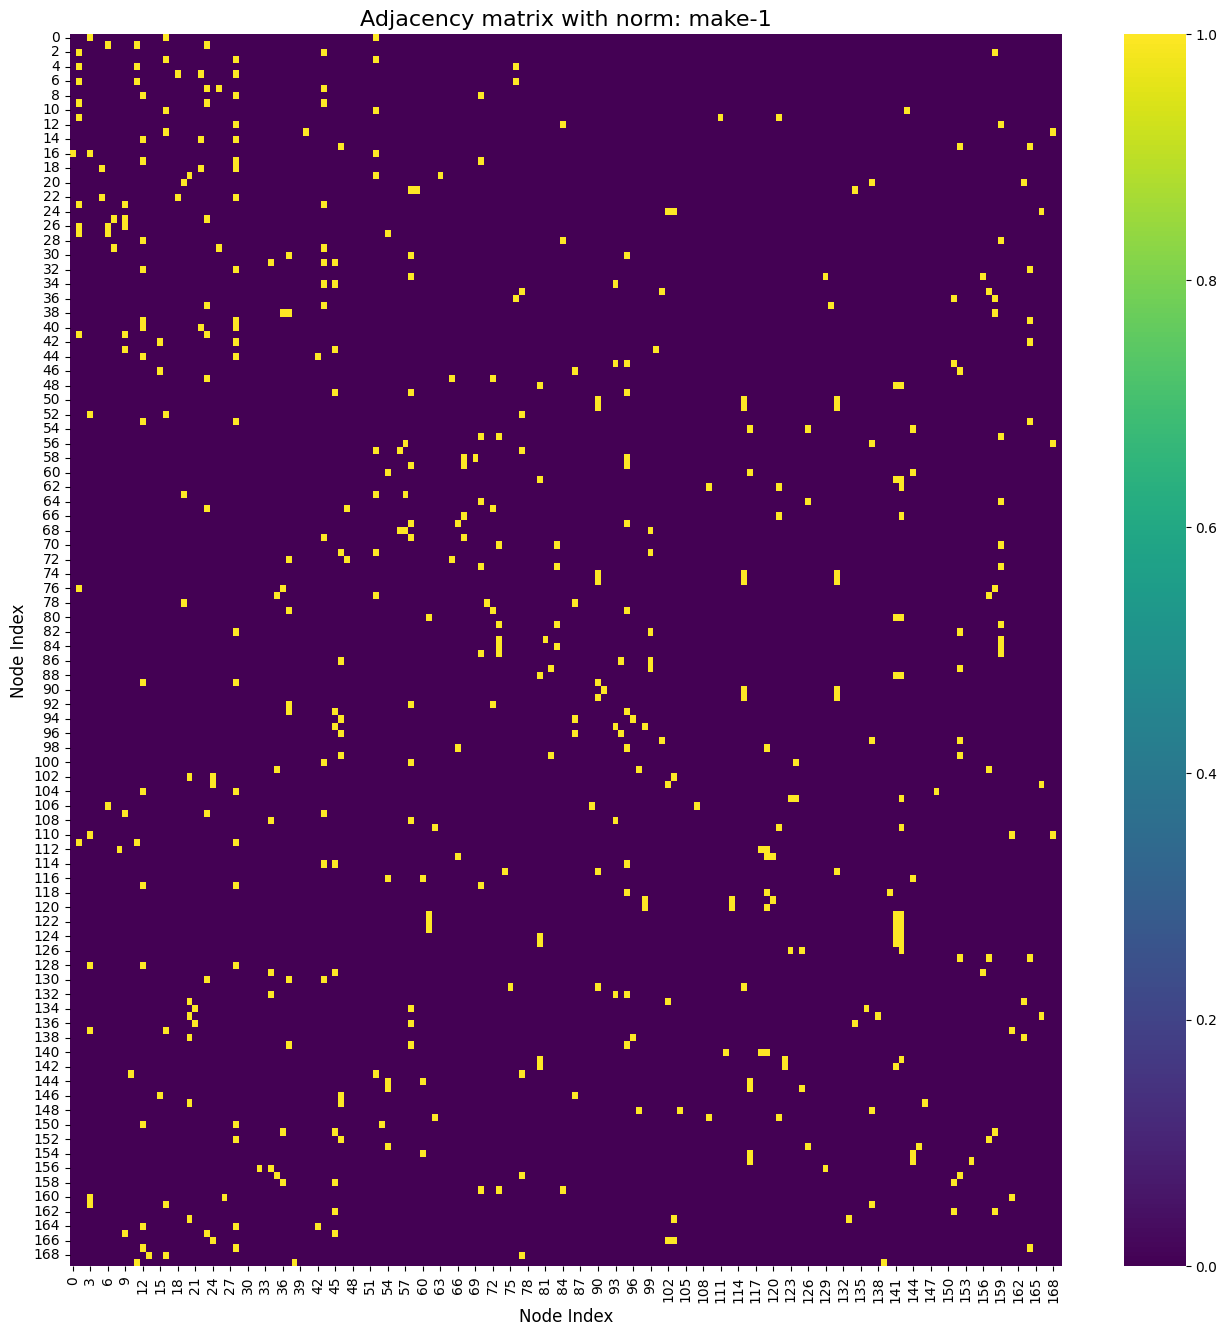

In [67]:
for norm in [None, 'row-l1', 'row-softmax', 'softmax', 'row-minmax', 'minmax', 'make-1']:
    own_adj = top_k_adjacency_matrix(corr_matrix, 3, norm)
    print(f'\nNORM: {norm}\n',calculate_graph_metrics(own_adj))
    plot_adjacency_matrix_heatmap(own_adj, f'Adjacency matrix with norm: {norm}')

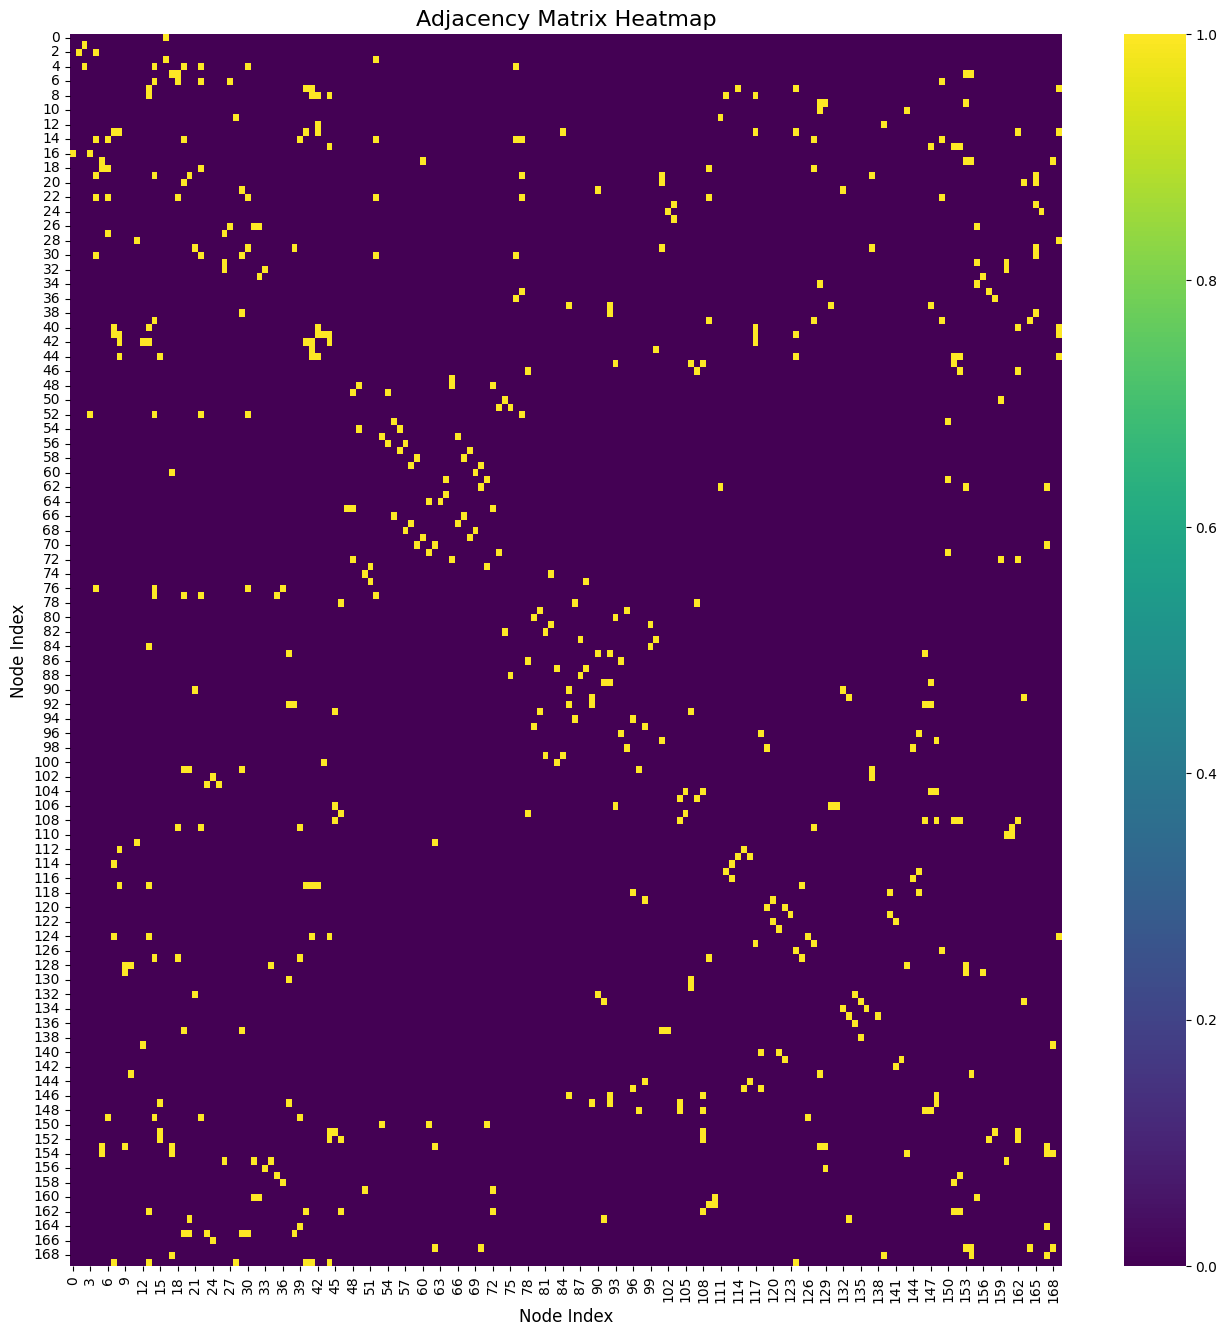

In [68]:
plot_adjacency_matrix_heatmap(adj_mx)

So there are some basic adjacency matrixes. Now lets list the big ammount of problems there are:
1. Matrixes tend to be preprocessed  for each network, which makes one think that the choice of network will affect the choice of matrix, thus rendering most normalization efforts useless. Essentially, make-1 would be the norm used in 99% of cases. So this is _kind_ of solved.
2. Number of nodes is a fixed value. This would in principle destroy things like very informative nodes, although it may be mitigated by the fact that the matrix is not symetric, so 'super-nodes' can still exist. We can see a clear case (PEMS-08) with node 52.
3. What direction should high correlation make our edges be? Right now, Corr(X, Y) in top-k means edge X->Y. But it could also mean edge Y->X. We might need to lag variables to make a better decision? 
4. The matrixes are not symmetrical. Obviously related to point 3. This may be a problem for some networks, and advantage for others...

Before starting to solve these problems I want to make a sanity check: lets create some measures of similarity between matrixes. Even now there are a few things to account for, these being:
- Transformed matrixes, specifically the doubletransition used for traffic ones (so the only test ones we have) are dumb so long as we are using a hardcoded k value, as the degree matrix is just going to be a diagonal identity
- Matrixes shouldn't neccesarily be similar, in fact, we may want them to not be so. If this (whole idea) was to be *very* right, naive matrix generation is not optimal and so our matrixes being similar to those would not be ideal

So, choices I will now make and continue coding: For now I will ignore the matrix normalization problem. We can just use make-1 if needed, or keep some normalization for networks that could benefit from it. Essentially it is model dependent which should not be as important
I will compare original matrixes to make-1 and get an absolute difference, and transform both as well.
Correlation is clearly too weak in this case, specialy for directed graphs. So I should look into other measures. Adaptative number of k should also be looked into. Matrix symmetry will be ignored for now, but it might come back if some network actually requires it.
Right now I am going to do two things: do the sanity test and make the matrix usable as input for the existing models, this is, learn how to save the matrix and create a config file to run the model with it.

First come functions to compare matrixes

In [69]:
def compare_adjacency_matrices(A: np.ndarray, B: np.ndarray):
    """
    Compare two adjacency matrices A and B.
    Both should be square numpy arrays of the same shape.
    
    Returns a dictionary of similarity metrics:
        - num_nodes
        - num_edges_A / num_edges_B
        - avg_degree_A / avg_degree_B
        - edge_difference (absolute difference in number of edges)
        - total_error (sum of absolute differences)
        - error_per_node (total_error / num_nodes)
        - common_edges (number of edges present in both)
        - jaccard_similarity (common_edges / union_edges)
    """
    if A.shape != B.shape:
        raise ValueError("Adjacency matrices must have the same shape")
    if A.shape[0] != A.shape[1]:
        raise ValueError("Adjacency matrices must be square")

    # Ensure binary (if weights are possible)
    A_bin = (A > 0).astype(int)
    B_bin = (B > 0).astype(int)
    
    num_nodes = A.shape[0]

    num_edges_A = np.sum(A_bin)
    num_edges_B = np.sum(B_bin)
    
    avg_degree_A = num_edges_A / num_nodes
    avg_degree_B = num_edges_B / num_nodes

    # Difference (for matrices with some processing)
    diff_matrix = np.abs(A - B)
    total_error = np.sum(diff_matrix)
    error_per_node = total_error / num_nodes
    # Absolute difference (existence of edge)
    diff_matrix = np.abs(A_bin - B_bin)
    total_bin_error = np.sum(diff_matrix)
    bin_error_per_node = total_bin_error / num_nodes
    
    # Common and union edges
    common_edges = np.sum((A_bin == 1) & (B_bin == 1))
    union_edges = np.sum((A_bin == 1) | (B_bin == 1))
    # Overlap similarity
    jaccard_similarity = common_edges / union_edges if union_edges > 0 else 1.0

    return {
        "num_nodes": num_nodes,
        "num_edges_A": int(num_edges_A),
        "num_edges_B": int(num_edges_B),
        "avg_degree_A": float(avg_degree_A),
        "avg_degree_B": float(avg_degree_B),
        "edge_difference": int(abs(num_edges_A - num_edges_B)),
        "total_error":float(total_error),
        "error_per_node":float(error_per_node),
        "total_bin_error": int(total_bin_error),
        "bin_error_per_node": float(bin_error_per_node),
        "common_edges": int(common_edges),
        "jaccard_similarity": float(jaccard_similarity),
    }


In [70]:
(own_adj.T)
for i in range(own_adj.shape[0]):
    if sum(adj_mx[i,:]) == 0:
        print(f'Error in line {i}')


In [71]:
(own_adj*own_adj.T)[1]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [72]:
calculate_transition_matrix(own_adj)

matrix([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.33333334, 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]], dtype=float32)

In [73]:
import numpy as np


def compare_adjacency_matrices_advanced(A: np.ndarray, B: np.ndarray):
    """
    Compare two adjacency matrices A and B (possibly directed, weighted).
    Returns only native Python types (no NumPy scalars).
    """
    if A.shape != B.shape:
        raise ValueError("Adjacency matrices must have the same shape")

    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    num_nodes = A.shape[0]

    A_bin = (A > 0).astype(int)
    B_bin = (B > 0).astype(int)

    # --- Basic structure ---
    num_edges_A = int(np.sum(A_bin))
    num_edges_B = int(np.sum(B_bin))
    avg_degree_A = float(num_edges_A / num_nodes)
    avg_degree_B = float(num_edges_B / num_nodes)

    # --- Error metrics ---
    abs_error_weighted = float(np.sum(np.abs(A - B)))
    abs_error_binary = float(np.sum(np.abs(A_bin - B_bin)))
    frobenius_error = float(np.linalg.norm(A - B, 'fro'))
    error_per_node_weighted = float(abs_error_weighted / num_nodes)
    error_per_node_binary = float(abs_error_binary / num_nodes)

    # --- Overlap metrics ---
    common_edges = int(np.sum((A_bin == 1) & (B_bin == 1)))
    union_edges = int(np.sum((A_bin == 1) | (B_bin == 1)))
    jaccard_similarity = float(common_edges / (union_edges + 1e-12))

    # --- Cosine & Pearson similarities ---
    cosine_similarity = float(
        np.dot(A.flatten(), B.flatten()) /
        (np.linalg.norm(A) * np.linalg.norm(B) + 1e-12)
    )
    pearson_corr = float(np.corrcoef(A.flatten(), B.flatten())[0, 1])

    # --- Edge-level classification metrics ---
    tp = common_edges
    fp = int(np.sum((A_bin == 0) & (B_bin == 1)))
    fn = int(np.sum((A_bin == 1) & (B_bin == 0)))
    precision = float(tp / (tp + fp + 1e-12))
    recall = float(tp / (tp + fn + 1e-12))
    f1_score = float(2 * precision * recall / (precision + recall + 1e-12))

    # --- Node-level degree correlations ---
    out_deg_A, in_deg_A = np.sum(A, axis=1), np.sum(A, axis=0)
    out_deg_B, in_deg_B = np.sum(B, axis=1), np.sum(B, axis=0)
    out_corr = float(np.corrcoef(out_deg_A, out_deg_B)[0, 1])
    in_corr = float(np.corrcoef(in_deg_A, in_deg_B)[0, 1])

    # --- Graph-level spectral measures ---
    def safe_eigvals(M):
        try:
            eigvals = np.linalg.eigvals(M)
            eigvals = np.real(eigvals)
            eigvals.sort()
            return eigvals
        except np.linalg.LinAlgError:
            return np.zeros(num_nodes)

    eig_A = safe_eigvals(A)
    eig_B = safe_eigvals(B)
    spectral_distance = float(np.linalg.norm(eig_A - eig_B))

    L_A = np.diag(np.sum(A, axis=1)) - A
    L_B = np.diag(np.sum(B, axis=1)) - B
    eig_LA = safe_eigvals(L_A)
    eig_LB = safe_eigvals(L_B)
    laplacian_spectral_distance = float(np.linalg.norm(eig_LA - eig_LB))
    graph_energy_diff = float(np.abs(np.sum(eig_A**2) - np.sum(eig_B**2)))

    return {
        # Basic info
        "num_nodes": int(num_nodes),
        "num_edges_A": num_edges_A,
        "num_edges_B": num_edges_B,
        "avg_degree_A": avg_degree_A,
        "avg_degree_B": avg_degree_B,

        # Error metrics
        "abs_error_weighted": abs_error_weighted,
        "abs_error_binary": abs_error_binary,
        "error_per_node_weighted": error_per_node_weighted,
        "error_per_node_binary": error_per_node_binary,
        "frobenius_error": frobenius_error,

        # Overlap / classification
        "common_edges": common_edges,
        "jaccard_similarity": jaccard_similarity,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,

        # Correlations
        "cosine_similarity": cosine_similarity,
        "pearson_corr": pearson_corr,
        "out_degree_corr": out_corr,
        "in_degree_corr": in_corr,

        # Spectral / global measures
        "spectral_distance": spectral_distance,
        "laplacian_spectral_distance": laplacian_spectral_distance,
        "graph_energy_diff": graph_energy_diff,
    }

In [74]:
compare_adjacency_matrices_advanced(own_adj, adj_mx)

c:\Work\Minerva\gnns\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Work\Minerva\gnns\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'num_nodes': 170,
 'num_edges_A': 510,
 'num_edges_B': 548,
 'avg_degree_A': 3.0,
 'avg_degree_B': 3.223529411764706,
 'abs_error_weighted': 848.0,
 'abs_error_binary': 848.0,
 'error_per_node_weighted': 4.988235294117647,
 'error_per_node_binary': 4.988235294117647,
 'frobenius_error': 29.120439557122072,
 'common_edges': 105,
 'jaccard_similarity': 0.11017838405036715,
 'precision': 0.19160583941605805,
 'recall': 0.20588235294117604,
 'f1_score': 0.1984877126649067,
 'cosine_similarity': 0.19861586305289708,
 'pearson_corr': 0.18368548626423153,
 'out_degree_corr': nan,
 'in_degree_corr': -0.24424279356970932,
 'spectral_distance': 11.739933450982104,
 'laplacian_spectral_distance': 23.26340078652017,
 'graph_energy_diff': 361.2580765156571}

In [75]:
def save_pkl(data_object: object, output_file: str):
    """
    Saves a Python object to a pickle file.

    Args:
        data_object (object): The object (e.g., np.ndarray, np.matrix, list) to be saved.
        pickle_file (str): The destination path for the pickle file.
    """
    try:
        # 'wb' mode opens the file for writing in binary mode
        with open(output_file, 'w+b') as f:
            pickle.dump(data_object, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Object successfully saved to {output_file}")
        
    except Exception as e:
        print(f'Error: Unable to save data to {output_file}: {e}')
        raise


In [76]:
#save_pkl(own_adj, './outputs_expl/matrixTest1.pkl')

So matrixes run correctly, and the results seem to actually be positive, with improvements using the new matrixes. Sanity test passed and looking good. <br>Now let's move onto making some better matrixes. I will start with the adaptative k number as I am more knowledgeable there. I will need to further investigate other correlation measures before actually using them


For the first test I am just going to build a matrix giiving each node as many neighbours as it has in the original one. This is just to test whether it would improve similarity, as it can't be used on data without a pre-built matrix

In [77]:
def neighbour_k_adjacency_matrix(corr_matrix: np.ndarray, initial_matrix: np.ndarray, normalize: 'str' = None, norm_strength: float = 1) -> np.ndarray:
    """
    Creates a sparser adjacency matrix by selecting the top-k strongest
    correlations (edges) for each node and applying row-wise normalization.

    Args:
        corr_matrix (np.ndarray): The N x N Pearson correlation matrix.
        k (int): The number of outgoing connections to keep for each node.
        normalize (str): Options: 'row-l1', 'row-softmax', 'softmax', 'row-minmax', 'minmax', 'make-1. If None, no normalization is applied. Make-1 will make chosen edges 1.
        strength: if normalizing, allows for adjustment of normalization strength by modulating the division. A norm_strenth of 2 on a L1 norm will make elements sum to 2
    Returns:
        np.ndarray: The N x N sparse adjacency matrix.
    """
    N = corr_matrix.shape[0]

    # Make sure matrix is positive
    adj = np.abs(corr_matrix)
    np.fill_diagonal(adj, 0)  # Remove self-loops

    # Create a mask to keep only the top-k values for each row
    mask = np.zeros_like(adj, dtype=bool)
    binary_adj = (initial_matrix > 1e-6).astype(int)
    
    degrees = np.sum(binary_adj, axis=1) 
    # For each node (row)
    for i in range(N):
        # Get the *indices* that would sort the row by weight (in descending order). np already does this
        # np.argsort returns ascending, so we use [::-1] to reverse it
        k = degrees[i]
        top_k_indices = np.argsort(adj[i, :])[::-1][:k]
        mask[i, top_k_indices] = True # fill in the mask accordingly
        
    # Apply the mask: marvels of numpy
    sparse_adj = np.where(mask, adj, 0)
    if normalize:
        global_min = sparse_adj[sparse_adj > 0].min() if np.any(sparse_adj > 0) else 0
        global_max = sparse_adj.max()
        zero_mask = sparse_adj < 1e-6 # for methods that would affect 0s, we don't actually want them to be modified

        if normalize == 'row-l1':
            # Row-wise L1 normalization (sum of each row = norm_strength)
            row_sums = sparse_adj.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1  # Avoid division by zero
            normalized_adj = norm_strength * sparse_adj / row_sums
            
        elif normalize == 'row-softmax':
            # Row-wise Softmax: Exponentiate and normalize each row sum to 1
            exp_adj = np.exp(sparse_adj)
            exp_adj[zero_mask] = 0 # reset original 0 to 0
            row_sums = exp_adj.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1 
            normalized_adj = norm_strength * exp_adj / row_sums
            
        elif normalize == 'softmax':
            # Global Softmax: Normalize all elements by the sum of all elements
            exp_adj = np.exp(sparse_adj)
            exp_adj[zero_mask] = 0 # reset original 0 to 0
            global_sum = exp_adj.sum()
            normalized_adj = norm_strength * exp_adj / global_sum
            
        elif normalize == 'row-minmax':
            # Row-wise Min-Max normalization
            # Note: Since the values are already between 0 and 1, this mostly handles the post-sparsification range
            normalized_adj = np.copy(sparse_adj)
            for i in range(N):
                row = sparse_adj[i, :]
                row_min = row[row > 0].min() if np.any(row > 0) else 0
                row_max = row.max()
                
                denominator = row_max - row_min
                if denominator > 1e-6:
                    normalized_adj[i, :][~zero_mask[i,:]] = (row[~zero_mask[i,:]] - row_min) / denominator
                else:
                    normalized_adj[i, :] = row # Keep as is if all values are the same
            
        elif normalize == 'minmax':
            # Global Min-Max normalization
            denominator = global_max - global_min
            normalized_adj = np.copy(sparse_adj)
            if denominator > 1e-6:
                # Apply normalization only to the non-zero elements. ~ negates the mask
                normalized_adj[~zero_mask] = (sparse_adj[~zero_mask] - global_min) / denominator
                # Zero elements remain zero
        elif normalize == 'make-1':
            normalized_adj = (~zero_mask) # we can just cast the matrix here
        else:
            print(f"Warning: Unknown normalization type '{normalize}'. No normalization applied.")
            return sparse_adj

        return normalized_adj.astype(np.float32)

    else:
        return sparse_adj.astype(np.float32)

In [78]:
same_k_own_adj = neighbour_k_adjacency_matrix(corr_matrix, raw_input_matrix, 'make-1')

In [79]:
calculate_graph_metrics(same_k_own_adj)

{'num_nodes': 170,
 'total_edges': 548,
 'density': 0.019074138531152106,
 'avg_connection_strength': 1.0,
 'clustering_coefficient': 2.237581423101785e-05,
 'min_degree': 1,
 'max_degree': 28,
 'mean_degree': 6.447058823529412,
 'median_degree': 6.0,
 'mode_degree': 7,
 'std_degree': 4.0014876126494325,
 'q1_degree': 4.0,
 'q3_degree': 8.0,
 'reciprocity': 0.1332116788321168,
 'mean_in_degree': 3.223529411764706,
 'mean_out_degree': 3.223529411764706}

In [80]:
calculate_graph_metrics(adj_mx)

{'num_nodes': 170,
 'total_edges': 548,
 'density': 0.019074138531152106,
 'avg_connection_strength': 1.0,
 'clustering_coefficient': 9.944806324896822e-05,
 'min_degree': 2,
 'max_degree': 18,
 'mean_degree': 6.447058823529412,
 'median_degree': 4.0,
 'mode_degree': 4,
 'std_degree': 3.602306066471836,
 'q1_degree': 4.0,
 'q3_degree': 8.0,
 'reciprocity': 0.5,
 'mean_in_degree': 3.223529411764706,
 'mean_out_degree': 3.223529411764706}

In [81]:
compare_adjacency_matrices(same_k_own_adj, adj_mx), compare_adjacency_matrices(own_adj, adj_mx)

({'num_nodes': 170,
  'num_edges_A': 548,
  'num_edges_B': 548,
  'avg_degree_A': 3.223529411764706,
  'avg_degree_B': 3.223529411764706,
  'edge_difference': 0,
  'total_error': 868.0,
  'error_per_node': 5.105882167816162,
  'total_bin_error': 868,
  'bin_error_per_node': 5.105882352941176,
  'common_edges': 114,
  'jaccard_similarity': 0.11608961303462322},
 {'num_nodes': 170,
  'num_edges_A': 510,
  'num_edges_B': 548,
  'avg_degree_A': 3.0,
  'avg_degree_B': 3.223529411764706,
  'edge_difference': 38,
  'total_error': 848.0,
  'error_per_node': 4.9882354736328125,
  'total_bin_error': 848,
  'bin_error_per_node': 4.988235294117647,
  'common_edges': 105,
  'jaccard_similarity': 0.11017838405036726})

Well there goes the test. Clearly the new matrixes have quite little in relation to the default ones. Which I would be inclined to expect. Running the tests a few times more continue with pretty similar results: custom matrixes end up with slightly better results

But then again, it was a short test. Now I'd like to build some kind of algorithm to dynamically allocate _k_ (number of neighbours) to each node. How to go about this... <br> Question: do we want the graph to be connected? The original is, but then again, we have better performance...

I am going to start by creating a function that generates the adjacency matrix given the correlation matrix and the edges (as a np mask). Then, I'll implement several methods for creating this mask. The final version would need to be refractored bc this will be written ugly.
I'm implementing:
- Top-K global ranking <br>
    Choose the top K edges with the most correlation
- Degree-regularized greedy selection <br>
    Choose edges one by one, penalising high degrees via a parameter
- Threshold-with-budget search <br>
    Finds a Correlation threshold above which edges are created. Yields results very similar to top-k but has slight flexibility
- Spectral sparsification <br>
    Sparcify the graph in such a way that certain properties of the Laplacian matrix (Degree-Adjacency) are kept (within what's possible)
    This maintains the results of some operations (difussion, *random walks*) pretty much the same, which is great for many networks (like DCRNN and friends). The computational cost is, however, quite significant, so I am going to try and have two implementations, an aproximated one and an exact one
- K-NN-with-global-budget hybrid <br>
    A mix of my original row-based knn and of the global one. Will allow for the creation of super-nodes but will limit them to a certain extent, thus preventing the extreme clustering around very few nodes that global top-k (can) generate.
- D’Hondt-style proportional allocation

And I have considered, but not implemented:
- Probabilistic edge sampling <br>
    Too random, I don't see how we would explain anything too much, and results could vary wildly
- Heuristic graph balancing / edge swapping <br>
    Most methods are already trying to implement this: maximum correlation while avoiding an excess of super-nodes and preserving structure as much as possible. Given this is a mask that works on top of an already sparce matrix I don't see the point
- Multi-objective optimization (correlation + degree fairness) <br>
    The greedy algorithm already attempts to do this. Now, we could implement an exact solver with some kind of optimizer, but how about we do NOT GET THE SIMPLEX INSIDE THIS TOO
    

In [82]:
def top_k_row_mask(corr_matrix: np.ndarray, k: int):
    """
    Selects the top k strongest correlations for each node and returns a boolean mask marking those positions.
    Args:
        corr_matrix (np.ndarray): N x N correlation or similarity matrix.
        total_edges (int): Desired total number of edges for each node
    Returns:
        np.ndarray: Boolean mask (N x N) where True indicates selected edges.
    """
    adj = np.abs(corr_matrix)
    np.fill_diagonal(adj, 0)  # Remove self-loops

    # Create a mask to keep only the top-k values for each row
    mask = np.zeros_like(adj, dtype=bool)

    # For each node (row)
    for i in range(corr_matrix.shape[0]):
        # Get the *indices* that would sort the row by weight (in descending order). np already does this
        # np.argsort returns ascending, so we use [::-1] to reverse it
        top_k_indices = np.argsort(adj[i, :])[::-1][:k]
        mask[i, top_k_indices] = True  # fill in the mask accordingly
    return mask


def global_top_e_mask(corr_matrix: np.ndarray, total_edges: int, directed: bool = True) -> np.ndarray:
    """
    Selects the globally strongest 'total_edges' correlations from the matrix
    and returns a boolean mask marking those positions.

    Args:
        corr_matrix (np.ndarray): N x N correlation or similarity matrix.
        total_edges (int): Desired total number of edges in the final adjacency.
        directed (bool): If False, ensures symmetry (i.e., undirected graph). Duplicates number of edges!
                         If True (default), treats matrix as directed and selects top E individually.

    Returns:
        np.ndarray: Boolean mask (N x N) where True indicates selected edges.
    """
    N = corr_matrix.shape[0]
    abs_corr = np.abs(corr_matrix).copy()
    np.fill_diagonal(abs_corr, 0)  # remove self-loops

    if directed:
        # Flatten the whole matrix
        flat_indices = np.argsort(abs_corr, axis=None)[::-1][:total_edges]
        mask = np.zeros_like(abs_corr, dtype=bool).flatten()
        mask[flat_indices] = True
        mask = mask.reshape(N, N)
    else:
        # Work only on upper triangle to avoid double counting
        triu_indices = np.triu_indices(N, k=1)
        edge_strengths = abs_corr[triu_indices]
        # Get indices of the top 'E' strongest edges
        top_e_idx = np.argsort(edge_strengths)[::-1][:total_edges]
        # Build mask
        mask = np.zeros_like(abs_corr, dtype=bool)
        top_rows = triu_indices[0][top_e_idx]
        top_cols = triu_indices[1][top_e_idx]
        mask[top_rows, top_cols] = True
        mask[top_cols, top_rows] = True  # make symmetric

    return mask


def degree_regularized_greedy_mask(corr_matrix: np.ndarray, total_edges: int, penalty_factor: float = 0.1, directed: bool = False,) -> np.ndarray:
    """
    Selects edges greedily based on correlation strength and degree regularization.

    Args:
        corr_matrix (np.ndarray): N x N correlation or similarity matrix.
        total_edges (int): Desired total number of edges in the graph.
        penalty_factor (float): Penalty factor for high-degree nodes.
                                Larger values = more uniform degree distribution. > 1 will cause top-k due to correlation being <1
        directed (bool): If True, treat matrix as directed; otherwise symmetric (default True). 
        Duplicates number od edges in undirected graphs

    Returns:
        np.ndarray: Boolean mask (N x N) with True for selected edges.
    """
    N = corr_matrix.shape[0]
    W = np.abs(corr_matrix).copy()
    np.fill_diagonal(W, 0)  # avoid self loops
    degrees = np.zeros(N, dtype=int)
    mask = np.zeros_like(W, dtype=bool)
    if directed:
        # Consider all possible edges
        edge_indices = [(i, j) for i in range(N) for j in range(N) if i != j]
    else:
        # Only upper triangle (we're going to reflect this)
        edge_indices = [(i, j) for i in range(N) for j in range(i + 1, N)]

    # Sort all edges by initial weight descending
    edge_indices.sort(key=lambda x: W[x[0], x[1]], reverse=True)

    selected_edges = 0
    while selected_edges < total_edges and edge_indices:
        best_edge = None
        best_score = -np.inf

        # Evaluate candidate scores
        for (i, j) in edge_indices:
            # we should consider our hub definition
            score = W[i, j] - penalty_factor * (degrees[i] + degrees[j])
            # TODO: define hubs correctly at some point
            if score > best_score:
                best_score = score
                best_edge = (i, j)

        if best_edge is None:
            break  # no more edges can be added. Prevents infinity

        i, j = best_edge
        mask[i, j] = True
        if not directed:
            mask[j, i] = True
        degrees[i] += 1
        degrees[j] += 1
        selected_edges += 1

        # Remove that edge from candidate list
        edge_indices.remove(best_edge)

    return mask


def threshold_with_budget_mask(corr_matrix: np.ndarray, total_edges: int, directed: bool = True, tol: float = 0.02) -> np.ndarray:
    """
    Builds a mask by finding a correlation threshold that yields approximately
    'total_edges' edges.

    Args:
        corr_matrix (np.ndarray): N x N correlation or similarity matrix.
        total_edges (int): Desired total number of edges in the final graph.
        directed (bool): If False, ensure symmetry (will duplicate edge number)
        tol (float): Relative tolerance for number of edges (0 to 1).

    Returns:
        np.ndarray: Boolean mask (N x N) with True where edges are selected.
    """
    N = corr_matrix.shape[0]
    abs_corr = np.abs(corr_matrix).copy()
    # this could, in theory, still be selected, so we wil re-clear them
    np.fill_diagonal(abs_corr, 0)

    # Only use upper triangle for undirected
    if directed:
        values = abs_corr.flatten()
    else:
        values = abs_corr[np.triu_indices(N, k=1)]

    values.sort()
    values = values[::-1]  # descending order
    num_edges_available = len(values)

    # This method will crash if we ask for more edges than N^2
    if total_edges >= num_edges_available:
        mask = np.ones_like(abs_corr, dtype=bool)
        np.fill_diagonal(mask, 0)
        return mask

    # Binary search for threshold that yields near total_edges
    low, high = 0, 1
    best_tau = 0
    target_min = total_edges * (1 - tol)
    target_max = total_edges * (1 + tol)

    while low < high:
        tau = (low + high) / 2
        if directed:
            count = np.sum(abs_corr > tau)
        else:
            count = np.sum(np.triu(abs_corr, 1) > tau)

        if target_min <= count <= target_max:
            best_tau = tau
            break
        elif count > total_edges:
            low = tau  # too many edges, raise threshold
        else:
            high = tau  # too few edges, lower threshold

        # prevent infinite loop for discrete matrices
        if abs(high - low) < 1e-6:
            best_tau = tau
            break

    # Build final mask
    mask = abs_corr > best_tau
    if not directed:
        mask = np.triu(mask, 1)  # not really needed
        mask = mask | mask.T

    np.fill_diagonal(mask, 0)
    return mask


def knn_with_global_budget_mask(corr_matrix: np.ndarray, total_edges: int, k_local: int = 8, directed: bool = True,) -> np.ndarray:
    """
    Hybrid sparsification combining local K-NN and a global edge budget.

    Args:
        corr_matrix (np.ndarray): N x N correlation (or similarity) matrix.
        total_edges (int): Desired total number of edges.
        k_local (int): Number of local strongest neighbors per node (for KNN).
        directed (bool): If False, output is symmetric (undirected).

    Returns:
        np.ndarray: Boolean N x N mask of selected edges.
    """
    N = corr_matrix.shape[0]
    abs_corr = np.abs(corr_matrix).copy()
    np.fill_diagonal(abs_corr, 0)

    # select edges in each row
    knn_mask = np.zeros_like(abs_corr, dtype=bool)
    for i in range(N):
        top_idx = np.argsort(abs_corr[i, :])[::-1][:k_local]
        knn_mask[i, top_idx] = True

    if not directed:
        knn_mask = np.logical_or(knn_mask, knn_mask.T)

    # from the original selection trim until we have less than the global budget
    current_edges = np.count_nonzero(knn_mask)
    if not directed:
        current_edges //= 2  # account for symmetry

    if current_edges > total_edges:
        # Rank edges by correlation strength and keep top total_edges
        if directed:
            scores = abs_corr[knn_mask]
            threshold = np.partition(scores, -total_edges)[-total_edges]
            final_mask = np.logical_and(knn_mask, abs_corr >= threshold)
        else:
            triu_mask = np.triu(knn_mask, k=1)
            scores = abs_corr[triu_mask]
            top_idx = np.argsort(scores)[::-1][:total_edges]
            mask = np.zeros_like(abs_corr, dtype=bool)
            triu_indices = np.triu_indices(N, k=1)
            selected_rows = triu_indices[0][top_idx]
            selected_cols = triu_indices[1][top_idx]
            mask[selected_rows, selected_cols] = True
            mask[selected_cols, selected_rows] = True
            final_mask = mask
    else:
        final_mask = knn_mask

    return final_mask

In [83]:
def _kruskal_mst_edges(N: int, edge_list: np.ndarray) -> np.ndarray:
    """
    Kruskal MST (descending weights) to ensure connectivity.
    edge_list: array of shape (M, 3) -> (u, v, weight)
    Returns boolean mask edges_selected (M,) True if edge chosen.
    """
    # Union-Find
    parent = np.arange(N)
    rank = np.zeros(N, dtype=int)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra == rb:
            return False
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[rb] < rank[ra]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1
        return True

    M = edge_list.shape[0]
    selected = np.zeros(M, dtype=bool)
    # edges already expected to be sorted by weight descending
    for idx in range(M):
        u, v, _w = edge_list[idx]
        if union(int(u), int(v)):
            selected[idx] = True
    return selected


def spectral_sparsification_proxy_mask(corr_matrix: np.ndarray, total_edges: int, ensure_connected: bool = True, eps: float = 1e-12,) -> np.ndarray:
    """
    Fast spectral-sparsification proxy: uses a resistance-like proxy
    score s_ij = W_ij * (1/(deg_i) + 1/(deg_j)) to rank edges, optionally
    adding an MST first to guarantee connectivity.

    Args:
        corr_matrix (np.ndarray): (N, N) symmetric correlation matrix.
        total_edges (int): Desired total number of undirected edges (E).
        ensure_connected (bool): If True, include an MST (N-1 edges) first.
        eps (float): small constant to avoid division by zero.

    Returns:
        mask (np.ndarray): boolean (N, N) symmetric mask of selected edges.
    """
    if corr_matrix.ndim != 2 or corr_matrix.shape[0] != corr_matrix.shape[1]:
        raise ValueError("corr_matrix must be square (N x N).")

    N = corr_matrix.shape[0]
    if total_edges < 0:
        raise ValueError("total_edges must be non-negative.")
    # Maximum possible undirected edges
    max_edges = N * (N - 1) // 2
    if total_edges >= max_edges:
        mask = np.ones((N, N), dtype=bool)
        np.fill_diagonal(mask, False)
        return mask

    # 1) weights and basic prep
    W = np.abs(corr_matrix).astype(float).copy()
    np.fill_diagonal(W, 0.0)

    # 2) compute weighted degrees
    deg = W.sum(axis=1)  # shape (N,)
    # avoid zeros
    inv_deg = 1.0 / (deg + eps)

    # 3) build upper-triangle edge list
    iu, ju = np.triu_indices(N, k=1)
    weights = W[iu, ju]
    # compute proxy score s_ij = W_ij * (1/deg_i + 1/deg_j)
    scores = weights * (inv_deg[iu] + inv_deg[ju])

    # Build structured edge array: (u, v, weight, score)
    # We'll sort by score descending (ties broken by weight)
    M = len(iu)
    edge_arr = np.empty((M, 4), dtype=float)
    edge_arr[:, 0] = iu
    edge_arr[:, 1] = ju
    edge_arr[:, 2] = weights
    edge_arr[:, 3] = scores

    # Sort edges by score descending, then by weight descending, thus the '-'
    order = np.lexsort((-edge_arr[:, 2], -edge_arr[:, 3]))
    edge_arr = edge_arr[order]

    selected_mask = np.zeros((N, N), dtype=bool)
    edges_selected = 0
    cursor = 0

    # 4) Ensure connectivity via MST (optional)
    if ensure_connected:
        # For MST we want to pick edges with largest *weight* to connect graph backbone.
        # Sort by weight descending for Kruskal
        # Build a copy sorted by weight descending
        weight_order = np.argsort(edge_arr[:, 2])[::-1]
        edges_by_weight = edge_arr[weight_order][:, :3]  # (u, v, weight)
        # MST selection returns boolean mask relative to edges_by_weight
        mst_selected_flags = _kruskal_mst_edges(N, edges_by_weight)
        # Map back selected edges to original edge_arr indices
        mst_indices_in_edge_arr = weight_order[mst_selected_flags]
        for idx in mst_indices_in_edge_arr:
            u = int(edge_arr[idx, 0])
            v = int(edge_arr[idx, 1])
            if not selected_mask[u, v]:
                selected_mask[u, v] = True
                selected_mask[v, u] = True
                edges_selected += 1
                if edges_selected >= total_edges:
                    break
        # continue selection from top scores, skipping already selected edges
    # 5) Fill remaining edges by descending score
    while edges_selected < total_edges and cursor < M:
        u = int(edge_arr[cursor, 0])
        v = int(edge_arr[cursor, 1])
        if not selected_mask[u, v]:
            selected_mask[u, v] = True
            selected_mask[v, u] = True
            edges_selected += 1
        cursor += 1

    return selected_mask

In [84]:
def resistance_spectral_sparsify(
    corr_matrix: np.ndarray,
    m: int,
    directed: bool = False,
    reweight: bool = True,
    pinv_tol: float = 1e-12,
    seed: int | None = None
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Resistance-based spectral sparsification (exact effective resistances via pseudoinverse).

    Args:
        corr_matrix (np.ndarray): N x N correlation or similarity matrix.
        m (int): Number of edges to sample (total undirected edges if directed=False).
        directed (bool): If True, treat matrix as directed (sample ordered pairs).
        reweight (bool): If True, reweight sampled edges by w_e / (m * p_e).
        pinv_tol (float): Tolerance passed to np.linalg.pinv (SVD cutoff).
        seed (int|None): RNG seed for reproducibility.

    Returns:
        tuple: (adj_matrix, mask, counts)
            adj_matrix (np.ndarray): N x N weighted adjacency matrix.
            mask (np.ndarray): Boolean N x N matrix, True where edges were selected.
            counts (np.ndarray): Integer N x N matrix, how many times each edge was sampled.
    """
    rng = np.random.default_rng(seed)

    N = corr_matrix.shape[0]
    if corr_matrix.shape[1] != N:
        raise ValueError("corr_matrix must be square")
    if m <= 0:
        raise ValueError("m must be positive")

    # 1. Make symmetric, positive weights
    W = np.abs(corr_matrix).astype(float)
    np.fill_diagonal(W, 0.0)
    if not directed:
        W = (W + W.T) / 2.0

    # 2. Laplacian
    deg = W.sum(axis=1)
    L = np.diag(deg) - W

    # 3. Pseudoinverse (Moore–Penrose)
    Lplus = np.linalg.pinv(L, rcond=pinv_tol)
    Lplus_diag = np.diag(Lplus)

    # 4. Build edge list
    if directed:
        edges = [(i, j) for i in range(N) for j in range(N) if i != j]
    else:
        edges = [(i, j) for i in range(N) for j in range(i + 1, N)]
    E = len(edges)

    if E == 0:
        return np.zeros((N, N), dtype=np.float32), np.zeros((N, N), dtype=bool), np.zeros((N, N), dtype=int)

    i_idx = np.array([e[0] for e in edges])
    j_idx = np.array([e[1] for e in edges])

    # 5. Effective resistances
    R = Lplus_diag[i_idx] + Lplus_diag[j_idx] - 2 * Lplus[i_idx, j_idx]
    R = np.maximum(R, 0.0)
    w_edges = W[i_idx, j_idx]

    # 6. Sampling probabilities
    scores = w_edges * R
    total_score = scores.sum()
    if total_score <= 0:
        scores = (w_edges > 0).astype(float)
        total_score = scores.sum()
    probs = scores / total_score

    # 7. Sample m edges (with replacement)
    sampled_indices = rng.choice(np.arange(E), size=m, replace=True, p=probs)
    counts_flat = np.bincount(sampled_indices, minlength=E)

    # 8. Build adjacency
    adj = np.zeros((N, N), dtype=np.float64)
    counts = np.zeros((N, N), dtype=int)

    for idx, cnt in enumerate(counts_flat):
        if cnt == 0:
            continue
        i, j = edges[idx]
        p_e = probs[idx]
        w_e = w_edges[idx]
        if reweight:
            contrib = cnt * (w_e / (m * p_e))
        else:
            contrib = cnt * w_e
        adj[i, j] += contrib
        counts[i, j] = cnt
        if not directed:
            adj[j, i] += contrib
            counts[j, i] = cnt

    mask = adj > 0.0

    return adj.astype(np.float32), mask, counts


The following two methods are my complete invention so I guess they warrant some explanation. <br>
They are based on electoral systems in order to allocate edges with a certain fairness. There are two ways of doing this: total sum and highest correlation. The difference being, in one, the 'votes' is the sum of correlations with that node, in the other, it is the highest correlation of that node. Second one keeps local neighbourhoods better vs the global capacity of the first one.

In [85]:
def dhondt_proportional_allocation_sum_correlation(corr_matrix: np.ndarray, total_edges: int, directed: bool = True) -> np.ndarray:
    """
    D'Hondt-style proportional allocation sparsification.
    Each node receives edges in proportion to its total correlation mass,
    balancing high-connectivity nodes with fair degree distribution.

    Args:
        corr_matrix (np.ndarray): N x N correlation or similarity matrix.
        total_edges (int): Total number of edges desired.
        directed (bool): Whether to treat graph as directed.

    Returns:
        np.ndarray: Boolean adjacency mask (N x N).
    """
    N = corr_matrix.shape[0]
    abs_corr = np.abs(corr_matrix).copy()
    np.fill_diagonal(abs_corr, 0)  # remove self links
    mask = np.zeros_like(abs_corr, dtype=bool)
    degrees = np.zeros(N, dtype=int)

    # Total connection strength for each node
    vote_weights = abs_corr.sum(axis=1)
    edge_count = 0

    # Neighbours (seats chosen) pre sorted
    sorted_neighbors = [np.argsort(abs_corr[i, :])[::-1] for i in range(N)]

    while edge_count < total_edges:
        # D’Hondt quotients
        quotients = vote_weights / (degrees + 1)

        # Pick node with highest quotient
        i = np.argmax(quotients)

        # Find its best available neighbor
        for j in sorted_neighbors[i]:
            if i == j or mask[i, j]:
                continue
            mask[i, j] = True
            if not directed:
                mask[j, i] = True
            degrees[i] += 1
            degrees[j] += 1
            edge_count += 1
            break  # assign one edge per iteration

        # Safety break to avoid infinite loops
        if edge_count >= total_edges or not np.any(~mask):
            break

    return mask


def dhondt_top_edge_allocation_mask(corr_matrix: np.ndarray, total_edges: int, directed: bool = True) -> np.ndarray:
    """
    D'Hondt-style proportional allocation using node top-edge priority.

    Each node's current "vote weight" is its highest remaining correlation edge.
    Once an edge is chosen, the node's next highest remaining edge becomes its new weight.

    Args:
        corr_matrix (np.ndarray): N x N correlation or similarity matrix.
        total_edges (int): Total number of edges desired.
        directed (bool): Whether to treat the graph as directed.

    Returns:
        np.ndarray: Boolean adjacency mask (N x N).
    """
    N = corr_matrix.shape[0]
    abs_corr = np.abs(corr_matrix).copy()
    np.fill_diagonal(abs_corr, 0)
    mask = np.zeros_like(abs_corr, dtype=bool)
    degrees = np.zeros(N, dtype=int)

    # Precompute sorted neighbor indices for each node
    sorted_neighbors = [list(np.argsort(abs_corr[i, :])[::-1])
                        for i in range(N)]

    edge_count = 0
    while edge_count < total_edges:
        # Compute each node's current top-edge
        top_edge_values = np.zeros(N)
        top_edge_neighbors = np.full(N, -1, dtype=int)
        for i in range(N):
            # Skip already chosen edges
            while sorted_neighbors[i] and mask[i, sorted_neighbors[i][0]]:
                sorted_neighbors[i].pop(0)
            if sorted_neighbors[i]:
                top_edge_neighbors[i] = sorted_neighbors[i][0]
                top_edge_values[i] = abs_corr[i, top_edge_neighbors[i]]
            else:
                top_edge_values[i] = 0  # no remaining edges

        # Compute D’Hondt quotients
        quotients = top_edge_values / (degrees + 1)
        if np.all(quotients == 0):
            break  # no more assignable edges

        # Pick node with highest quotient
        i_star = np.argmax(quotients)
        j_star = top_edge_neighbors[i_star]

        if j_star == -1:
            break  # no available neighbor

        # Assign edge
        mask[i_star, j_star] = True
        if not directed:
            mask[j_star, i_star] = True
        degrees[i_star] += 1
        degrees[j_star] += 1
        edge_count += 1

    return mask

In [86]:
def make_adjacency_matrix(corr_matrix: np.ndarray, k: int, mask: str = None, normalize: str = None, norm_strength: float = 1) -> np.ndarray:
    """
    Creates a sparser adjacency matrix by selecting the top-k strongest
    correlations (edges) for each node and applying row-wise normalization.

    Args:
        corr_matrix (np.ndarray): The N x N Pearson correlation matrix.
        k (int): The number of TOTAL outgoing connections to keep
        mask (str): Options: 'top-k-row', 'top-k-global', 'greedy-degree-regularize', 'threshold-mask', 
        'spectral-sparce', 'strict-spectral-sparce', 'top-k-row-global-limit', 'dhont-corr-sum', 'dhont-top-edge'
        normalize (str): Options: 'row-l1', 'row-softmax', 'softmax', 'row-minmax', 'minmax', 'make-1. If None, no normalization is applied. Make-1 will make chosen edges 1.
        strength: if normalizing, allows for adjustment of normalization strength by modulating the division. A norm_strenth of 2 on a L1 norm will make elements sum to 2
    Returns:
        np.ndarray: The N x N sparse adjacency matrix.
    """
    N = corr_matrix.shape[0]

    # Make sure matrix is positive
    adj = np.abs(corr_matrix)
    mask_matrix = None
    if mask == 'top-k-row':
        edges_per_neighbour = int(k/N)
        mask_matrix = top_k_row_mask(corr_matrix, edges_per_neighbour)
    elif mask == 'top-k-global':
        mask_matrix = global_top_e_mask(corr_matrix, k, True)
    elif mask == 'greedy-degree-regularize':
        mask_matrix = degree_regularized_greedy_mask(corr_matrix, k, 0.1, True) # We need to allow params to enter here
    elif mask == 'threshold-mask':
        mask_matrix = threshold_with_budget_mask(corr_matrix, k)
    elif mask =='spectral-sparce':
        mask_matrix = spectral_sparsification_proxy_mask(corr_matrix, k)
    elif mask == 'strict-spectral-sparce':
        mask_matrix = resistance_spectral_sparsify(corr_matrix, k)[0]
    elif mask == 'top-k-row-global-limit':
        mask_matrix = knn_with_global_budget_mask(corr_matrix, k, k//N * 3)
    elif mask == 'dhont-corr-sum':
        mask_matrix = dhondt_proportional_allocation_sum_correlation(corr_matrix, k)
    elif mask == 'dhont-top-edge':
        mask_matrix = dhondt_top_edge_allocation_mask(corr_matrix, k)
        
    # Apply the mask: marvels of numpy
    sparse_adj = np.where(mask_matrix, adj, 0)
    if normalize:
        global_min = sparse_adj[sparse_adj >
                                0].min() if np.any(sparse_adj > 0) else 0
        global_max = sparse_adj.max()
        # for methods that would affect 0s, we don't actually want them to be modified
        zero_mask = sparse_adj < 1e-6

        if normalize == 'row-l1':
            # Row-wise L1 normalization (sum of each row = norm_strength)
            row_sums = sparse_adj.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1  # Avoid division by zero
            normalized_adj = norm_strength * sparse_adj / row_sums

        elif normalize == 'row-softmax':
            # Row-wise Softmax: Exponentiate and normalize each row sum to 1
            exp_adj = np.exp(sparse_adj)
            exp_adj[zero_mask] = 0  # reset original 0 to 0
            row_sums = exp_adj.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            normalized_adj = norm_strength * exp_adj / row_sums

        elif normalize == 'softmax':
            # Global Softmax: Normalize all elements by the sum of all elements
            exp_adj = np.exp(sparse_adj)
            exp_adj[zero_mask] = 0  # reset original 0 to 0
            global_sum = exp_adj.sum()
            normalized_adj = norm_strength * exp_adj / global_sum

        elif normalize == 'row-minmax':
            # Row-wise Min-Max normalization
            # Note: Since the values are already between 0 and 1, this mostly handles the post-sparsification range
            normalized_adj = np.copy(sparse_adj)
            for i in range(N):
                row = sparse_adj[i, :]
                row_min = row[row > 0].min() if np.any(row > 0) else 0
                row_max = row.max()

                denominator = row_max - row_min
                if denominator > 1e-6:
                    normalized_adj[i, :][~zero_mask[i, :]] = (
                        row[~zero_mask[i, :]] - row_min) / denominator
                else:
                    # Keep as is if all values are the same
                    normalized_adj[i, :] = row

        elif normalize == 'minmax':
            # Global Min-Max normalization
            denominator = global_max - global_min
            normalized_adj = np.copy(sparse_adj)
            if denominator > 1e-6:
                # Apply normalization only to the non-zero elements. ~ negates the mask
                normalized_adj[~zero_mask] = (
                    sparse_adj[~zero_mask] - global_min) / denominator
                # Zero elements remain zero
        elif normalize == 'make-1':
            normalized_adj = (~zero_mask)  # we can just cast the matrix here
        else:
            print(
                f"Warning: Unknown normalization type '{normalize}'. No normalization applied.")
            return sparse_adj

        return normalized_adj.astype(np.float32)

    else:
        return sparse_adj.astype(np.float32)

A few notes: we can easily see why thresholds and global-top-k are not the greatest ideas if we plot the heatmap: some nodes will keep almost all edges, generating a pretty weird structure that I'm pretty sure wouldn't actually work. Why this could happen: there are probaly straitedge sections of the road with several sensors (doing traffic) which makes some series have way higher correlation. However using only one edge between these series would do the job, and would allow us to keep the rest of the network more connected. Possibly, some measure that takes conditionality would solve this kind of stuff (think of three sensors in a row, which right now would be connected, but we dont actually need to connect 1->3 if 2 is in between and connected) <br>
Some more: about spectral based sparcification: the results look beautiful and, on paper, would be great for spectral gnns. Might not be so good for mpgnns. Now, the exact algorithm is not deterministic. This gives us another question: would performing each step of training on a different, resistance-sparcified matrix yield interesting results?

In [87]:
compare_adjacency_matrices_advanced(make_adjacency_matrix(corr_matrix, 255, 'strict-spectral-sparce', ), make_adjacency_matrix(corr_matrix, 255, 'strict-spectral-sparce', ))

{'num_nodes': 170,
 'num_edges_A': 508,
 'num_edges_B': 506,
 'avg_degree_A': 2.988235294117647,
 'avg_degree_B': 2.976470588235294,
 'abs_error_weighted': 788.3295756578445,
 'abs_error_binary': 990.0,
 'error_per_node_weighted': 4.637232797987321,
 'error_per_node_binary': 5.823529411764706,
 'frobenius_error': 25.375516947657534,
 'common_edges': 12,
 'jaccard_similarity': 0.011976047904191605,
 'precision': 0.0237154150197628,
 'recall': 0.02362204724409444,
 'f1_score': 0.023668639052754393,
 'cosine_similarity': 0.02292873157161222,
 'pearson_corr': 0.005923266596773668,
 'out_degree_corr': 0.12530376583491434,
 'in_degree_corr': 0.12530376583491434,
 'spectral_distance': 0.7703173313748007,
 'laplacian_spectral_distance': 1.859366612185148,
 'graph_energy_diff': 7.544106434665309}

In [104]:
temp = (make_adjacency_matrix(corr_matrix, 548, 'top-k-row', 'make-1'))

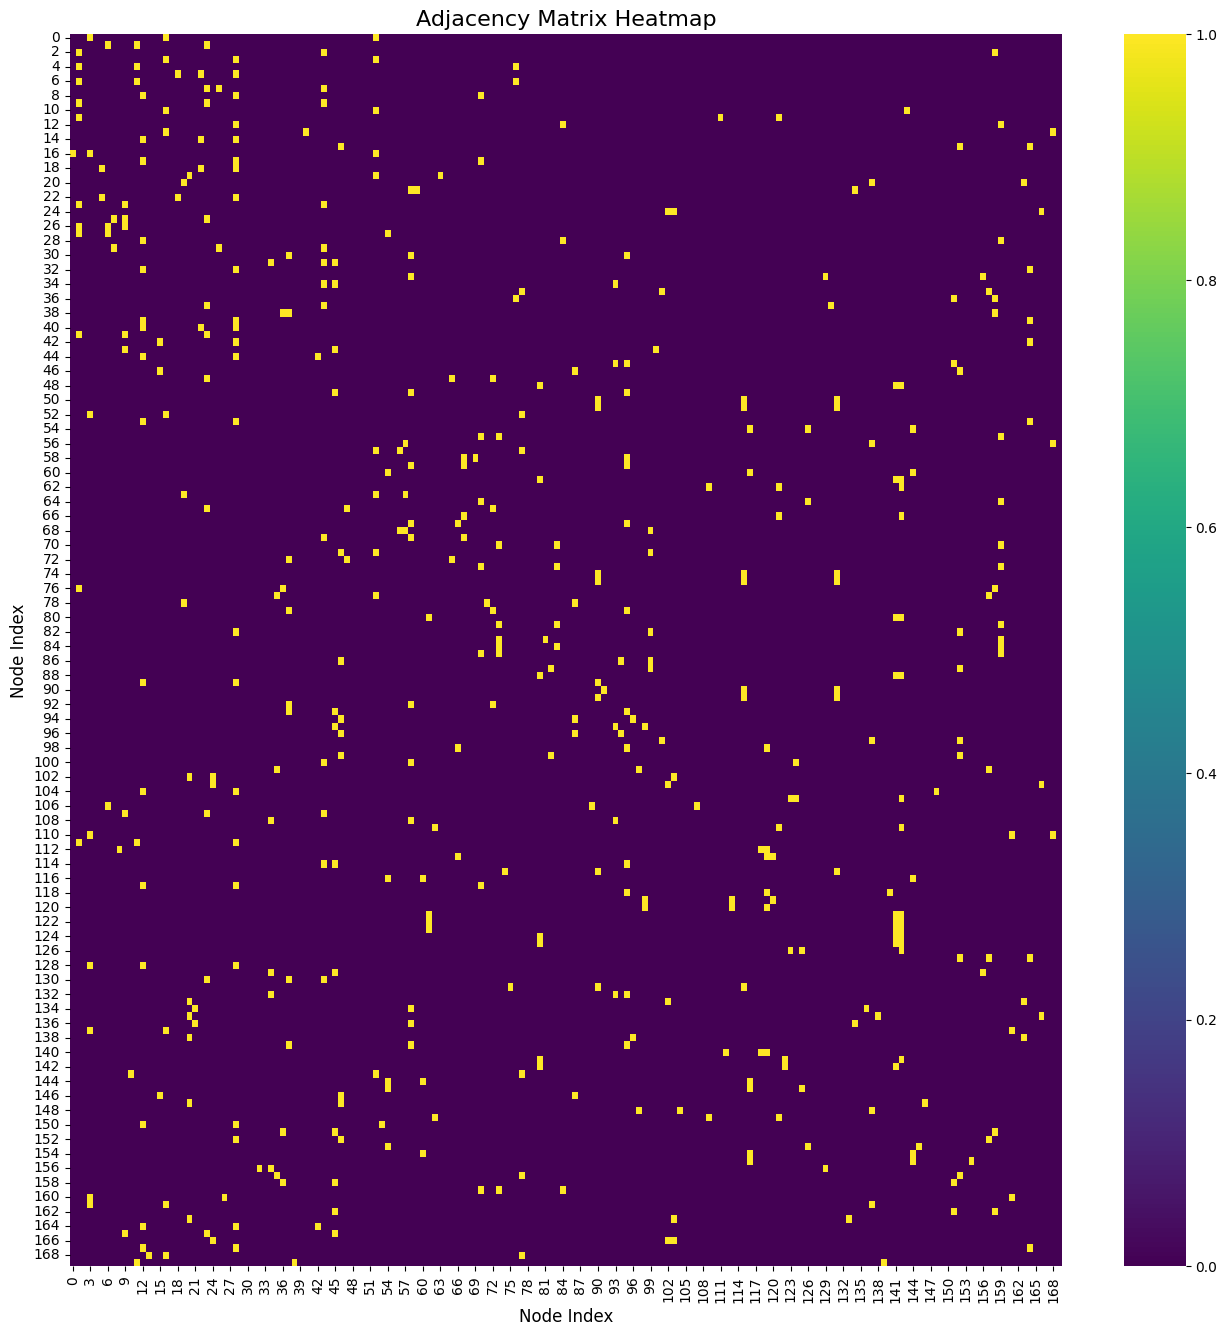

In [105]:
plot_adjacency_matrix_heatmap(temp)

In [106]:
save_pkl(temp, 'matrixTest1.pkl')

Object successfully saved to matrixTest1.pkl


In [90]:
calculate_graph_metrics(adj_mx)

{'num_nodes': 170,
 'total_edges': 548,
 'density': 0.019074138531152106,
 'avg_connection_strength': 1.0,
 'clustering_coefficient': 9.944806324896822e-05,
 'min_degree': 2,
 'max_degree': 18,
 'mean_degree': 6.447058823529412,
 'median_degree': 4.0,
 'mode_degree': 4,
 'std_degree': 3.602306066471836,
 'q1_degree': 4.0,
 'q3_degree': 8.0,
 'reciprocity': 0.5,
 'mean_in_degree': 3.223529411764706,
 'mean_out_degree': 3.223529411764706}

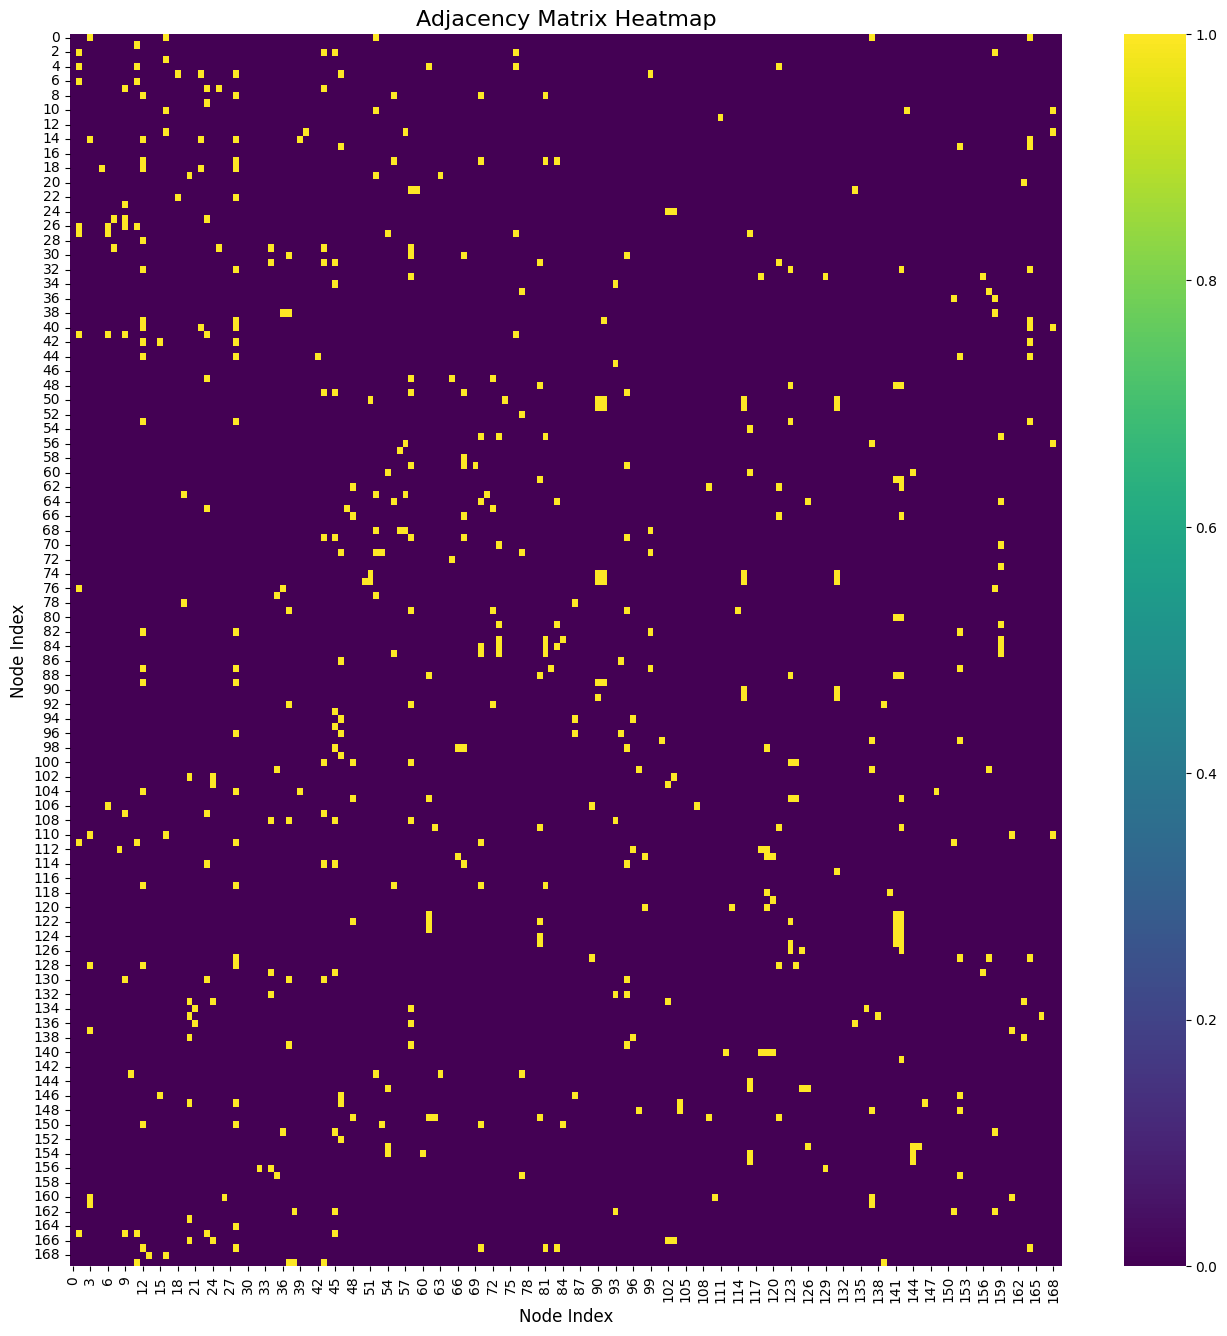

In [91]:
plot_adjacency_matrix_heatmap(make_adjacency_matrix(corr_matrix, 548, 'dhont-corr-sum', 'make-1'))

In [92]:
save_pkl(make_adjacency_matrix(corr_matrix, 548, 'dhont-corr-sum', 'make-1'), './outputs_expl/matrixTest1.pkl')

Error: Unable to save data to ./outputs_expl/matrixTest1.pkl: [Errno 2] No such file or directory: './outputs_expl/matrixTest1.pkl'


FileNotFoundError: [Errno 2] No such file or directory: './outputs_expl/matrixTest1.pkl'

In [ ]:
compare_adjacency_matrices(make_adjacency_matrix(corr_matrix, 510, 'greedy-degree-regularize', 'make-1'), make_adjacency_matrix(corr_matrix, 510, 'top-k-row', 'make-1'))

{'num_nodes': 170,
 'num_edges_A': 510,
 'num_edges_B': 510,
 'avg_degree_A': 3.0,
 'avg_degree_B': 3.0,
 'edge_difference': 0,
 'total_error': 548.0,
 'error_per_node': 3.22352933883667,
 'total_bin_error': 548,
 'bin_error_per_node': 3.223529411764706,
 'common_edges': 236,
 'jaccard_similarity': 0.3010204081632653}

In [ ]:
def is_connected(adj_matrix: np.ndarray) -> bool:
    """
    Check if the undirected graph represented by the adjacency matrix is connected.
    
    Parameters:
        adj_matrix (np.ndarray): Square adjacency matrix (n x n)
                                 where adj_matrix[i, j] > 0 indicates an edge.
    
    Returns:
        bool: True if the graph is connected, False otherwise.
    """
    n = adj_matrix.shape[0]
    if adj_matrix.shape[0] != adj_matrix.shape[1]:
        raise ValueError("Adjacency matrix must be square.")
    
    # Use BFS or DFS — here we use BFS
    visited = np.zeros(n, dtype=bool)
    stack = [0]  # start from node 0
    visited[0] = True
    
    while stack:
        node = stack.pop()
        # Get neighbors (nonzero entries)
        neighbors = np.where(adj_matrix[node] > 0)[0]
        for neigh in neighbors:
            if not visited[neigh]:
                visited[neigh] = True
                stack.append(neigh)
    
    return visited.all()